# modelo binario

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import re
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.decomposition import PCA
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import itertools
from scipy.stats import mannwhitneyu
from statsmodels.stats.multicomp import MultiComparison
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import shapiro, normaltest, anderson, jarque_bera
from scipy.stats import f_oneway, kruskal
from scipy.stats import levene, bartlett
warnings.filterwarnings('ignore')
from scipy.stats import spearmanr, kendalltau
from collections import defaultdict
from datetime import datetime
import os
from matplotlib.patches import Patch
from sklearn.preprocessing import LabelEncoder
from itertools import combinations
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import ttest_ind
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import DBSCAN
from collections import Counter
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import pdist, squareform
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from difflib import unified_diff, SequenceMatcher
import json

In [35]:
#1

file_path_original = 'C:/Users/ville/datos_final_20_10.xlsx'  # Cambia esto por la ubicación de tu archivo
df_original = pd.read_excel(file_path_original)
print(df)


# Cargar el archivo Excel (especifica la ruta correcta del archivo)
file_path = 'C:/Users/ville/datos_cobre_oro_limpio.xlsx'  # Cambia esto por la ubicación de tu archivo
df = pd.read_excel(file_path)
print(df)

file_path_unlabel = 'C:/Users/ville/unlabeled_data.xlsx'  # Cambia esto por la ubicación de tu archivo
X_unlabeled = pd.read_excel(file_path_unlabel)
print(df)

      Unnamed: 0   IDQ                          Faena Recurso  Cu(g/t)  \
0              0     1                     LA PATAGUA   COBRE     1772   
1              1     2            LAS CENIZAS CABILDO   COBRE     2616   
2              2     3            LAS CENIZAS CABILDO   COBRE      814   
3              3     4            LAS CENIZAS CABILDO   COBRE      528   
4              4     5            LAS CENIZAS CABILDO   COBRE      627   
...          ...   ...                            ...     ...      ...   
1353        2087  2153  EX PLANTA DEL GRINGO TICHAGUA     ORO      390   
1354        2088  2154  EX PLANTA DEL GRINGO TICHAGUA     ORO       31   
1355        2091  2157                     LA PATAGUA   COBRE      393   
1356        2117  2186                          TUINA   COBRE     8196   
1357        2118  2187                          TUINA   COBRE      388   

      V(g/t)  Cr(g/t)  Co(g/t)  Ni(g/t)  Zn(g/t)  ...  Gd(g/t)  Tb(g/t)  \
0         71       21       35      

In [36]:
#2
df_sin_faena = df.drop('Faena', axis=1)
df_sin_idq = df_sin_faena.drop('IDQ', axis=1)
df_sin_unn = df_sin_idq.drop('Unnamed: 0', axis=1)
df_cu_au = df_sin_unn

In [75]:
# Identificar columnas que contienen %
columnas_porcentaje = [col for col in df_original.columns if '%' in col]

# Crear el mapeo para nuevos nombres
mapeo_nombres = {}
for col in columnas_porcentaje:
    nuevo_nombre = col.replace('%', 'g/t')
    mapeo_nombres[col] = nuevo_nombre

# Aplicar la conversión y cambio de nombres
for col_vieja, col_nueva in mapeo_nombres.items():
    # Convertir valores: % a g/t (multiplicar por 10,000)
    df_original[col_nueva] = df_original[col_vieja] * 10000
    # Eliminar la columna original
    df_original.drop(col_vieja, axis=1, inplace=True)

print("Columnas convertidas:", columnas_porcentaje)

Columnas convertidas: ['S Total(%)', 'SiO2(%)', 'Al2O3(%)', 'TiO2(%)', 'Fe2O3(%)', 'CaO(%)', 'MgO(%)', 'MnO(%)', 'Na2O(%)', 'K2O(%)', 'P2O5(%)', 'PPC(%)', 'SO3(%)']


In [76]:
print(df_original.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1358 entries, 0 to 1357
Data columns (total 57 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Recurso       1358 non-null   object 
 1   Cu(g/t)       1358 non-null   int64  
 2   V(g/t)        1358 non-null   int64  
 3   Cr(g/t)       1358 non-null   int64  
 4   Co(g/t)       1358 non-null   int64  
 5   Ni(g/t)       1358 non-null   int64  
 6   Zn(g/t)       1358 non-null   int64  
 7   Rb(g/t)       1358 non-null   int64  
 8   Sr(g/t)       1358 non-null   int64  
 9   Y(g/t)        1358 non-null   int64  
 10  Zr(g/t)       1358 non-null   int64  
 11  Nb(g/t)       1358 non-null   int64  
 12  Ba(g/t)       1358 non-null   int64  
 13  Pb(g/t)       1358 non-null   int64  
 14  Sc(g/t)       1358 non-null   int64  
 15  Cs(g/t)       1358 non-null   float64
 16  Hf(g/t)       1358 non-null   float64
 17  Ta(g/t)       1358 non-null   float64
 18  Th(g/t)       1358 non-null 

In [78]:
print(df_cu_au.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1358 entries, 0 to 1357
Data columns (total 57 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Recurso       1358 non-null   object 
 1   Cu(g/t)       1358 non-null   int64  
 2   V(g/t)        1358 non-null   int64  
 3   Cr(g/t)       1358 non-null   int64  
 4   Co(g/t)       1358 non-null   int64  
 5   Ni(g/t)       1358 non-null   int64  
 6   Zn(g/t)       1358 non-null   int64  
 7   Rb(g/t)       1358 non-null   int64  
 8   Sr(g/t)       1358 non-null   int64  
 9   Y(g/t)        1358 non-null   int64  
 10  Zr(g/t)       1358 non-null   int64  
 11  Nb(g/t)       1358 non-null   int64  
 12  Ba(g/t)       1358 non-null   int64  
 13  Pb(g/t)       1358 non-null   int64  
 14  Sc(g/t)       1358 non-null   int64  
 15  Cs(g/t)       1358 non-null   float64
 16  Hf(g/t)       1358 non-null   float64
 17  Ta(g/t)       1358 non-null   float64
 18  Th(g/t)       1358 non-null 

In [77]:
# Identificar columnas que contienen %
columnas_porcentaje = [col for col in df_cu_au.columns if '%' in col]

# Crear el mapeo para nuevos nombres
mapeo_nombres = {}
for col in columnas_porcentaje:
    nuevo_nombre = col.replace('%', 'g/t')
    mapeo_nombres[col] = nuevo_nombre

# Aplicar la conversión y cambio de nombres
for col_vieja, col_nueva in mapeo_nombres.items():
    # Convertir valores: % a g/t (multiplicar por 10,000)
    df_cu_au[col_nueva] = df_cu_au[col_vieja] * 10000
    # Eliminar la columna original
    df_cu_au.drop(col_vieja, axis=1, inplace=True)

print("Columnas convertidas:", columnas_porcentaje)

Columnas convertidas: ['S Total(%)', 'SiO2(%)', 'Al2O3(%)', 'TiO2(%)', 'Fe2O3(%)', 'CaO(%)', 'MgO(%)', 'MnO(%)', 'Na2O(%)', 'K2O(%)', 'P2O5(%)', 'PPC(%)', 'SO3(%)']


In [79]:
recursos_au_cu = print(df_cu_au['Recurso'].value_counts())

COBRE    710
ORO      648
Name: Recurso, dtype: int64


In [39]:
print(df_cu_au.head())

  Recurso  Cu(g/t)  V(g/t)  Cr(g/t)  Co(g/t)  Ni(g/t)  Zn(g/t)  Rb(g/t)  \
0   COBRE     1772      71       21       35        7       90       62   
1   COBRE     2616      49       65       30       32      362       31   
2   COBRE      814      86       55       34       16      184       76   
3   COBRE      528      32       36       30       49       84       17   
4   COBRE      627     104       52       32       10       90       63   

   Sr(g/t)  Y(g/t)  ...  Gd(g/t)  Tb(g/t)  Dy(g/t)  Ho(g/t)  Er(g/t)  Tm(g/t)  \
0      144      10  ...     3.88     0.54     2.81     0.71     1.79     0.24   
1      161      10  ...     3.04     0.44     2.79     0.55     1.40     0.21   
2      210      10  ...     3.14     0.46     3.12     0.58     1.61     0.25   
3      110      10  ...     2.79     0.41     2.35     0.49     1.55     0.19   
4      189      10  ...     3.67     0.54     3.34     0.71     1.88     0.26   

   Yb(g/t)  Lu(g/t)  Au(g/t)  Hg(g/t)  
0     1.75     0.23   


MÉTODO 1: RFE con número fijo de features

Variables seleccionadas: 45

Ranking de variables (1 = mejor):
    Variable  Ranking  Seleccionada
     Cu(g/t)        1          True
     Ce(g/t)        1          True
     Pr(g/t)        1          True
     Nd(g/t)        1          True
     Sm(g/t)        1          True
     Eu(g/t)        1          True
     Gd(g/t)        1          True
     Dy(g/t)        1          True
     Er(g/t)        1          True
     Yb(g/t)        1          True
     Hg(g/t)        1          True
S Total(g/t)        1          True
   SiO2(g/t)        1          True
  Al2O3(g/t)        1          True
   TiO2(g/t)        1          True
  Fe2O3(g/t)        1          True
    CaO(g/t)        1          True
    MgO(g/t)        1          True
    MnO(g/t)        1          True
   Na2O(g/t)        1          True
    K2O(g/t)        1          True
   P2O5(g/t)        1          True
    PPC(g/t)        1          True
     Cd(g/t)        1        

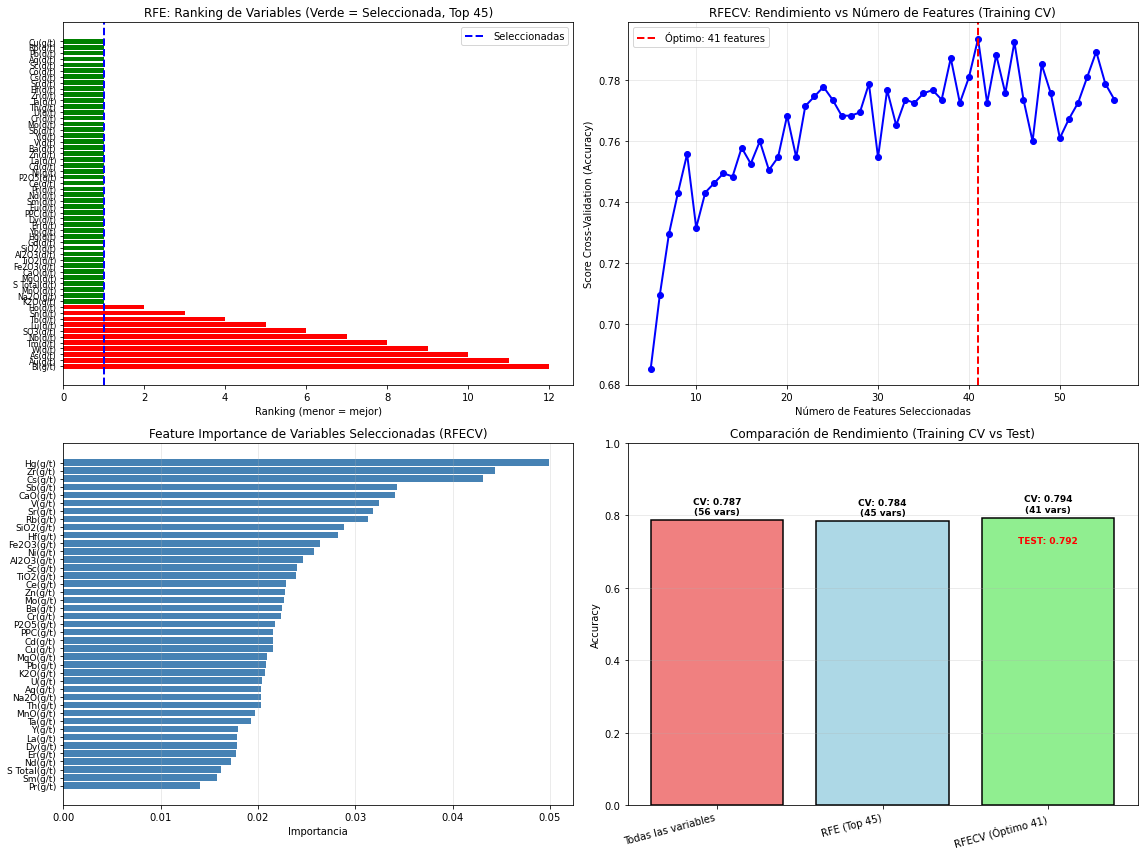


GUARDANDO RESULTADOS
✓ Ranking guardado en: rfe_ranking_variables.csv
✓ Variables seleccionadas guardadas en: variables_seleccionadas_rfecv.csv
✓ Dataset reducido guardado en: dataset_reducido_rfecv.csv
  (de 56 variables a 41 variables)
✓ Conjuntos de train y test reducidos guardados

ANÁLISIS COMPLETADO - SIN DATA LEAKAGE


In [80]:
#3 (6)

# Separar variables numéricas y clase categórica
X = df_cu_au.drop('Recurso', axis=1)  # Variables numéricas
y = df_cu_au['Recurso']  # Clase categórica

# Guardar copia del dataframe original para uso posterior
df_original = df_cu_au.copy()

# Separar en train/test (70/30) con el MISMO random_state
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30,
    random_state=42,  # ← MISMO que en Random Forest
    stratify=y
)

# Codificar clases categóricas a números (SOLO con training)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)  # Solo fit en train
y_test_encoded = le.transform(y_test)        # Solo transform en test

# Estandarizar variables (SOLO con training)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Solo fit en train
X_test_scaled = scaler.transform(X_test)        # Solo transform en test

# Crear DataFrames escalados
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\n" + "=" * 70)
print("MÉTODO 1: RFE con número fijo de features")
print("=" * 70)

# Definir el modelo estimador (puedes cambiar el modelo)
estimator = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Número de features que quieres seleccionar
n_features_to_select = min(45, X_train.shape[1])  # Seleccionar 45 o menos si hay pocas

# RFE con número fijo (SOLO con training data)
rfe = RFE(estimator=estimator, n_features_to_select=n_features_to_select)
rfe.fit(X_train_scaled, y_train_encoded)  # ← SOLO training data

# Obtener ranking de variables
ranking_df = pd.DataFrame({
    'Variable': X.columns,
    'Ranking': rfe.ranking_,
    'Seleccionada': rfe.support_
}).sort_values('Ranking')

print(f"\nVariables seleccionadas: {sum(rfe.support_)}")
print("\nRanking de variables (1 = mejor):")
print(ranking_df.to_string(index=False))

# Variables seleccionadas
selected_features = X.columns[rfe.support_].tolist()
print(f"\n{'='*70}")
print(f"Top {n_features_to_select} variables seleccionadas:")
print(f"{'='*70}")
for i, feat in enumerate(selected_features, 1):
    print(f"{i}. {feat}")

print("\n" + "=" * 70)
print("MÉTODO 2: RFECV - Selección automática con Cross-Validation")
print("=" * 70)

# RFECV encuentra automáticamente el número óptimo de features (SOLO con training)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rfecv = RFECV(
    estimator=estimator,
    step=1,  # Eliminar 1 variable a la vez
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    min_features_to_select=5  # Mínimo de features a mantener
)

rfecv.fit(X_train_scaled, y_train_encoded)  # ← SOLO training data

print(f"\nNúmero óptimo de features: {rfecv.n_features_}")
print(f"Mejor score (accuracy): {rfecv.cv_results_['mean_test_score'].max():.4f}")

# Variables seleccionadas por RFECV
selected_features_cv = X.columns[rfecv.support_].tolist()
print(f"\nVariables seleccionadas por RFECV:")
for i, feat in enumerate(selected_features_cv, 1):
    print(f"{i}. {feat}")

# Aplicar selección al conjunto de test
X_test_selected = X_test_scaled[:, rfecv.support_]

# Entrenar modelo final con features seleccionadas (SOLO training)
X_train_selected = X_train_scaled[:, rfecv.support_]
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train_selected, y_train_encoded)

# Evaluar en test set
y_pred = final_model.predict(X_test_selected)
test_accuracy = accuracy_score(y_test_encoded, y_pred)

print(f"\n{'='*70}")
print("EVALUACIÓN EN TEST SET")
print(f"{'='*70}")
print(f"Accuracy en TEST: {test_accuracy:.4f}")


# Crear visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Ranking de todas las variables (RFE)
ranking_sorted = ranking_df.sort_values('Ranking')
colors = ['green' if x else 'red' for x in ranking_sorted['Seleccionada']]
axes[0, 0].barh(range(len(ranking_sorted)), ranking_sorted['Ranking'], color=colors)
axes[0, 0].set_yticks(range(len(ranking_sorted)))
axes[0, 0].set_yticklabels(ranking_sorted['Variable'], fontsize=8)
axes[0, 0].set_xlabel('Ranking (menor = mejor)')
axes[0, 0].set_title(f'RFE: Ranking de Variables (Verde = Seleccionada, Top {n_features_to_select})')
axes[0, 0].invert_yaxis()
axes[0, 0].axvline(x=1, color='blue', linestyle='--', linewidth=2, label='Seleccionadas')
axes[0, 0].legend()

# 2. RFECV - Número de features vs Score
axes[0, 1].plot(range(rfecv.min_features_to_select, len(rfecv.cv_results_['mean_test_score']) + rfecv.min_features_to_select),
                rfecv.cv_results_['mean_test_score'], 'b-o', linewidth=2, markersize=6)
axes[0, 1].axvline(x=rfecv.n_features_, color='red', linestyle='--', 
                   linewidth=2, label=f'Óptimo: {rfecv.n_features_} features')
axes[0, 1].set_xlabel('Número de Features Seleccionadas')
axes[0, 1].set_ylabel('Score Cross-Validation (Accuracy)')
axes[0, 1].set_title('RFECV: Rendimiento vs Número de Features (Training CV)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Importancia de features seleccionadas (Feature Importance del modelo)
importance_df = pd.DataFrame({
    'Variable': selected_features_cv,
    'Importancia': final_model.feature_importances_
}).sort_values('Importancia', ascending=True)

axes[1, 0].barh(range(len(importance_df)), importance_df['Importancia'], color='steelblue')
axes[1, 0].set_yticks(range(len(importance_df)))
axes[1, 0].set_yticklabels(importance_df['Variable'], fontsize=9)
axes[1, 0].set_xlabel('Importancia')
axes[1, 0].set_title('Feature Importance de Variables Seleccionadas (RFECV)')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Comparación de scores
comparison_data = {
    'Método': ['Todas las variables', f'RFE (Top {n_features_to_select})', 
               f'RFECV (Óptimo {rfecv.n_features_})'],
    'N° Features': [X.shape[1], n_features_to_select, rfecv.n_features_]
}

# Calcular scores usando SOLO training data
model_full = RandomForestClassifier(n_estimators=100, random_state=42)
score_full = cross_val_score(model_full, X_train_scaled, y_train_encoded, cv=5, scoring='accuracy').mean()

model_rfe = RandomForestClassifier(n_estimators=100, random_state=42)
score_rfe = cross_val_score(model_rfe, X_train_scaled[:, rfe.support_], y_train_encoded, cv=5, scoring='accuracy').mean()

# Después de la línea del test_accuracy de RFECV, agregar:

# Evaluar modelo con todas las variables en test
model_full_test = RandomForestClassifier(n_estimators=100, random_state=42)
model_full_test.fit(X_train_scaled, y_train_encoded)
y_pred_full = model_full_test.predict(X_test_scaled)
test_accuracy_full = accuracy_score(y_test_encoded, y_pred_full)

# Evaluar modelo RFE en test
model_rfe_test = RandomForestClassifier(n_estimators=100, random_state=42)
model_rfe_test.fit(X_train_scaled[:, rfe.support_], y_train_encoded)
y_pred_rfe = model_rfe_test.predict(X_test_scaled[:, rfe.support_])
test_accuracy_rfe = accuracy_score(y_test_encoded, y_pred_rfe)

# Actualizar la tabla
comparison_data['Accuracy Test'] = [test_accuracy_full, test_accuracy_rfe, test_accuracy]


comparison_data['Accuracy CV'] = [score_full, score_rfe, rfecv.cv_results_['mean_test_score'].max()]


comparison_df = pd.DataFrame(comparison_data)
print(f"\n{'='*70}")
print("COMPARACIÓN DE RENDIMIENTO")
print(f"{'='*70}")
print(comparison_df.to_string(index=False))

# Gráfico de comparación
x_pos = range(len(comparison_df))
colors_comp = ['lightcoral', 'lightblue', 'lightgreen']
bars = axes[1, 1].bar(x_pos, comparison_df['Accuracy CV'], color=colors_comp, edgecolor='black', linewidth=1.5)
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(comparison_df['Método'], rotation=15, ha='right')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Comparación de Rendimiento (Training CV vs Test)')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Añadir valores sobre las barras
for i, (bar, acc_cv, n_feat) in enumerate(zip(bars, comparison_df['Accuracy CV'], comparison_df['N° Features'])):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'CV: {acc_cv:.3f}\n({n_feat} vars)',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# Añadir resultado de test para RFECV
axes[1, 1].text(2, test_accuracy - 0.05,
                f'TEST: {test_accuracy:.3f}',
                ha='center', va='top', fontsize=9, fontweight='bold', color='red')

plt.tight_layout()
plt.savefig('rfe_analisis_sin_leakage.png', dpi=300, bbox_inches='tight')
plt.show()

# Guardar resultados
print(f"\n{'='*70}")
print("GUARDANDO RESULTADOS")
print(f"{'='*70}")

# Guardar ranking completo
ranking_df.to_csv('rfe_ranking_variables.csv', index=False)
print("✓ Ranking guardado en: rfe_ranking_variables.csv")

# Guardar variables seleccionadas
pd.DataFrame({'Variable': selected_features_cv}).to_csv('variables_seleccionadas_rfecv.csv', index=False)
print("✓ Variables seleccionadas guardadas en: variables_seleccionadas_rfecv.csv")

# Guardar dataset reducido - usar el dataframe original
X_reduced = df_original[selected_features_cv + ['Recurso']].copy()
X_reduced.to_csv('dataset_reducido_rfecv.csv', index=False)
print(f"✓ Dataset reducido guardado en: dataset_reducido_rfecv.csv")
print(f"  (de {X.shape[1]} variables a {len(selected_features_cv)} variables)")

# Guardar también los conjuntos de train y test procesados
X_train_reduced = pd.DataFrame(X_train_scaled[:, rfecv.support_], columns=selected_features_cv)
X_train_reduced['Recurso'] = y_train_encoded
X_train_reduced.to_csv('train_reducido_rfecv.csv', index=False)

X_test_reduced = pd.DataFrame(X_test_scaled[:, rfecv.support_], columns=selected_features_cv)
X_test_reduced['Recurso'] = y_test_encoded
X_test_reduced.to_csv('test_reducido_rfecv.csv', index=False)

print("✓ Conjuntos de train y test reducidos guardados")

print("\n" + "=" * 70)
print("ANÁLISIS COMPLETADO - SIN DATA LEAKAGE")
print("=" * 70)


ANÁLISIS UMAP - FILTRADO PARA COBRE Y ORO
Dimensiones después del filtrado:
- Train original: (950, 56) -> Train filtrado: (950, 56)
- Test original: (408, 56) -> Test filtrado: (408, 56)
- Clases en train: (array(['COBRE', 'ORO'], dtype=object), array([497, 453], dtype=int64))
- Clases en test: (array(['COBRE', 'ORO'], dtype=object), array([213, 195], dtype=int64))
Aplicando UMAP a datos filtrados...
✓ UMAP completado


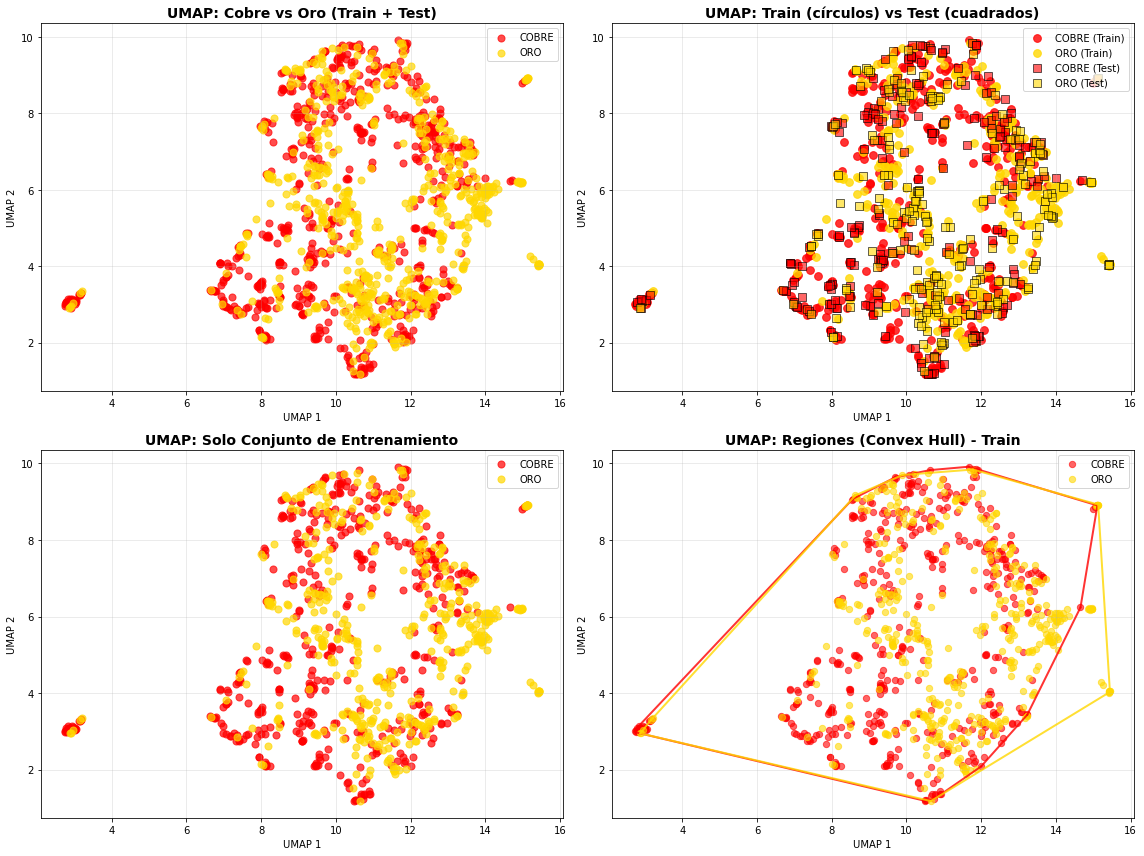


MÉTRICAS DE CALIDAD UMAP - COBRE vs ORO
UMAP - Conjunto de Entrenamiento (Cobre vs Oro):
  • Silhouette Score: 0.0393
  • Calinski-Harabasz Score: 42.5889
  • Interpretación: Alto solapamiento entre Cobre y Oro

Análisis de clusters (UMAP - Train):
  • COBRE: 497 muestras
    Centroide: [10.002, 5.560]
    Desviación: [2.317, 2.493]
  • ORO: 453 muestras
    Centroide: [11.358, 5.585]
    Desviación: [2.085, 2.091]
  • Distancia entre centroides: 1.356

GUARDANDO RESULTADOS UMAP - COBRE Y ORO
✓ Coordenadas UMAP guardadas en: coordenadas_umap_cobre_oro.csv
✓ Métricas UMAP guardadas en: metricas_umap_cobre_oro.csv

Resumen UMAP - Cobre vs Oro:
• Muestras totales: 1358 (Train: 950, Test: 408)
• Silhouette Score: 0.0393
• Separación: Alto solapamiento entre Cobre y Oro

ANÁLISIS UMAP COMPLETADO - COBRE Y ORO


In [41]:
#4
# =============================================================================
# ANÁLISIS UMAP - SOLO COBRE Y ORO
# =============================================================================

print("\n" + "=" * 70)
print("ANÁLISIS UMAP - FILTRADO PARA COBRE Y ORO")
print("=" * 70)

import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import numpy as np
import pandas as pd

# Filtrar solo las clases Cobre y Oro
clases_deseadas = ['COBRE', 'ORO']  # Ajusta los nombres según tus datos

# Crear máscaras para filtrar
mask_train = np.isin(y_train, clases_deseadas)
mask_test = np.isin(y_test, clases_deseadas)

# Aplicar filtro a los datos
X_train_filtered = X_train_scaled[mask_train]
y_train_filtered = y_train[mask_train]
X_test_filtered = X_test_scaled[mask_test]
y_test_filtered = y_test[mask_test]

# Codificar las clases filtradas
y_train_filtered_encoded = le.transform(y_train_filtered)
y_test_filtered_encoded = le.transform(y_test_filtered)

# Aplicar selección de features a los datos filtrados
X_train_selected = X_train_filtered[:, rfecv.support_]
X_test_selected = X_test_filtered[:, rfecv.support_]

# Combinar train + test para visualización completa
X_combined_selected = np.vstack([X_train_selected, X_test_selected])
y_combined_encoded = np.hstack([y_train_filtered_encoded, y_test_filtered_encoded])
y_combined_original = np.hstack([y_train_filtered, y_test_filtered])

print(f"Dimensiones después del filtrado:")
print(f"- Train original: {X_train_scaled.shape} -> Train filtrado: {X_train_filtered.shape}")
print(f"- Test original: {X_test_scaled.shape} -> Test filtrado: {X_test_filtered.shape}")
print(f"- Clases en train: {np.unique(y_train_filtered, return_counts=True)}")
print(f"- Clases en test: {np.unique(y_test_filtered, return_counts=True)}")

# Configurar UMAP
umap_reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean'
)

# Aplicar UMAP a datos filtrados
print("Aplicando UMAP a datos filtrados...")
X_umap = umap_reducer.fit_transform(X_combined_selected)
print("✓ UMAP completado")

# Identificar índices de train y test filtrados
train_size = len(X_train_selected)
test_size = len(X_test_selected)

# =============================================================================
# VISUALIZACIONES UMAP (COBRE Y ORO)
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Paleta de colores para Cobre y Oro
palette = {'COBRE': 'red', 'ORO': 'gold'}  # Colores apropiados para metales

# 1. UMAP - Todos los datos combinados (Cobre y Oro)
for class_name in clases_deseadas:
    mask = y_combined_original == class_name
    color = palette[class_name]
    axes[0, 0].scatter(
        X_umap[mask, 0], X_umap[mask, 1],
        color=color,
        label=class_name,
        alpha=0.7,
        s=50
    )
axes[0, 0].set_title('UMAP: Cobre vs Oro (Train + Test)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('UMAP 1')
axes[0, 0].set_ylabel('UMAP 2')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# 2. UMAP - Separado por Train/Test
# Train points
for class_name in clases_deseadas:
    mask = (y_train_filtered == class_name)
    color = palette[class_name]
    axes[0, 1].scatter(
        X_umap[:train_size, 0][mask], X_umap[:train_size, 1][mask],
        color=color,
        label=f'{class_name} (Train)',
        alpha=0.8,
        s=60,
        marker='o'
    )

# Test points
for class_name in clases_deseadas:
    mask = (y_test_filtered == class_name)
    color = palette[class_name]
    axes[0, 1].scatter(
        X_umap[train_size:, 0][mask], X_umap[train_size:, 1][mask],
        color=color,
        label=f'{class_name} (Test)',
        alpha=0.6,
        s=70,
        marker='s',
        edgecolor='black',
        linewidth=1.0
    )

axes[0, 1].set_title('UMAP: Train (círculos) vs Test (cuadrados)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('UMAP 1')
axes[0, 1].set_ylabel('UMAP 2')
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True, alpha=0.3)

# 3. UMAP - Solo Train (para análisis de clusters)
for class_name in clases_deseadas:
    mask = (y_train_filtered == class_name)
    color = palette[class_name]
    axes[1, 0].scatter(
        X_umap[:train_size, 0][mask], X_umap[:train_size, 1][mask],
        color=color,
        label=class_name,
        alpha=0.7,
        s=50
    )
axes[1, 0].set_title('UMAP: Solo Conjunto de Entrenamiento', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('UMAP 1')
axes[1, 0].set_ylabel('UMAP 2')
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(True, alpha=0.3)

# 4. UMAP - Convex Hull para mostrar regiones
from scipy.spatial import ConvexHull
for class_name in clases_deseadas:
    mask = (y_train_filtered == class_name)
    if np.sum(mask) >= 3:  # Mínimo 3 puntos para convex hull
        points = X_umap[:train_size][mask]
        hull = ConvexHull(points)
        color = palette[class_name]
        
        # Dibujar el convex hull
        for simplex in hull.simplices:
            axes[1, 1].plot(points[simplex, 0], points[simplex, 1], 
                           color=color, linewidth=2, alpha=0.8)
        
        # Dibujar puntos
        axes[1, 1].scatter(
            points[:, 0], points[:, 1],
            color=color,
            label=class_name,
            alpha=0.6,
            s=40
        )

axes[1, 1].set_title('UMAP: Regiones (Convex Hull) - Train', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('UMAP 1')
axes[1, 1].set_ylabel('UMAP 2')
axes[1, 1].legend(loc='upper right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('umap_cobre_oro.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# MÉTRICAS UMAP PARA COBRE Y ORO
# =============================================================================

print("\n" + "=" * 70)
print("MÉTRICAS DE CALIDAD UMAP - COBRE vs ORO")
print("=" * 70)

# Calcular métricas para UMAP (solo train filtrado)
silhouette_umap = silhouette_score(X_umap[:train_size], y_train_filtered_encoded)
calinski_umap = calinski_harabasz_score(X_umap[:train_size], y_train_filtered_encoded)

print(f"UMAP - Conjunto de Entrenamiento (Cobre vs Oro):")
print(f"  • Silhouette Score: {silhouette_umap:.4f}")
print(f"  • Calinski-Harabasz Score: {calinski_umap:.4f}")

# Interpretación del Silhouette Score
if silhouette_umap > 0.7:
    interpretation = "Separación excelente entre Cobre y Oro"
elif silhouette_umap > 0.5:
    interpretation = "Buena separación entre Cobre y Oro"
elif silhouette_umap > 0.25:
    interpretation = "Separación moderada, algo de solapamiento"
else:
    interpretation = "Alto solapamiento entre Cobre y Oro"

print(f"  • Interpretación: {interpretation}")

# =============================================================================
# ANÁLISIS ADICIONAL: DISTANCIAS ENTRE CLUSTERS
# =============================================================================

print(f"\nAnálisis de clusters (UMAP - Train):")
for class_name in clases_deseadas:
    mask = (y_train_filtered == class_name)
    n_samples = np.sum(mask)
    if n_samples > 0:
        class_points = X_umap[:train_size][mask]
        centroid = np.mean(class_points, axis=0)
        std = np.std(class_points, axis=0)
        print(f"  • {class_name}: {n_samples} muestras")
        print(f"    Centroide: [{centroid[0]:.3f}, {centroid[1]:.3f}]")
        print(f"    Desviación: [{std[0]:.3f}, {std[1]:.3f}]")

# Calcular distancia entre centroides
if len(clases_deseadas) == 2:
    mask_cobre = (y_train_filtered == clases_deseadas[0])
    mask_oro = (y_train_filtered == clases_deseadas[1])
    
    centroide_cobre = np.mean(X_umap[:train_size][mask_cobre], axis=0)
    centroide_oro = np.mean(X_umap[:train_size][mask_oro], axis=0)
    
    distancia = np.linalg.norm(centroide_cobre - centroide_oro)
    print(f"  • Distancia entre centroides: {distancia:.3f}")

# =============================================================================
# GUARDAR RESULTADOS UMAP
# =============================================================================

print("\n" + "=" * 70)
print("GUARDANDO RESULTADOS UMAP - COBRE Y ORO")
print("=" * 70)

# Crear DataFrame con las coordenadas UMAP
umap_coordinates = pd.DataFrame({
    'Dataset': ['train'] * train_size + ['test'] * test_size,
    'Clase_Original': y_combined_original,
    'Clase_Encoded': y_combined_encoded,
    'UMAP_1': X_umap[:, 0],
    'UMAP_2': X_umap[:, 1]
})

# Guardar coordenadas
umap_coordinates.to_csv('coordenadas_umap_cobre_oro.csv', index=False)
print("✓ Coordenadas UMAP guardadas en: coordenadas_umap_cobre_oro.csv")

# Guardar métricas
umap_metrics = pd.DataFrame({
    'Metrica': ['Silhouette_Score', 'Calinski_Harabasz_Score', 'Distancia_Centroides'],
    'Valor': [silhouette_umap, calinski_umap, distancia],
    'Interpretacion': [interpretation, 'Mayor valor = mejor separación', 'Distancia entre clusters']
})

umap_metrics.to_csv('metricas_umap_cobre_oro.csv', index=False)
print("✓ Métricas UMAP guardadas en: metricas_umap_cobre_oro.csv")

print(f"\nResumen UMAP - Cobre vs Oro:")
print(f"• Muestras totales: {len(X_combined_selected)} (Train: {train_size}, Test: {test_size})")
print(f"• Silhouette Score: {silhouette_umap:.4f}")
print(f"• Separación: {interpretation}")

print("\n" + "=" * 70)
print("ANÁLISIS UMAP COMPLETADO - COBRE Y ORO")
print("=" * 70)


ANÁLISIS t-SNE - FILTRADO PARA COBRE Y ORO
Usando datos filtrados para t-SNE:
- Train: (950, 55)
- Test: (408, 55)
Aplicando t-SNE a datos filtrados...
✓ t-SNE completado


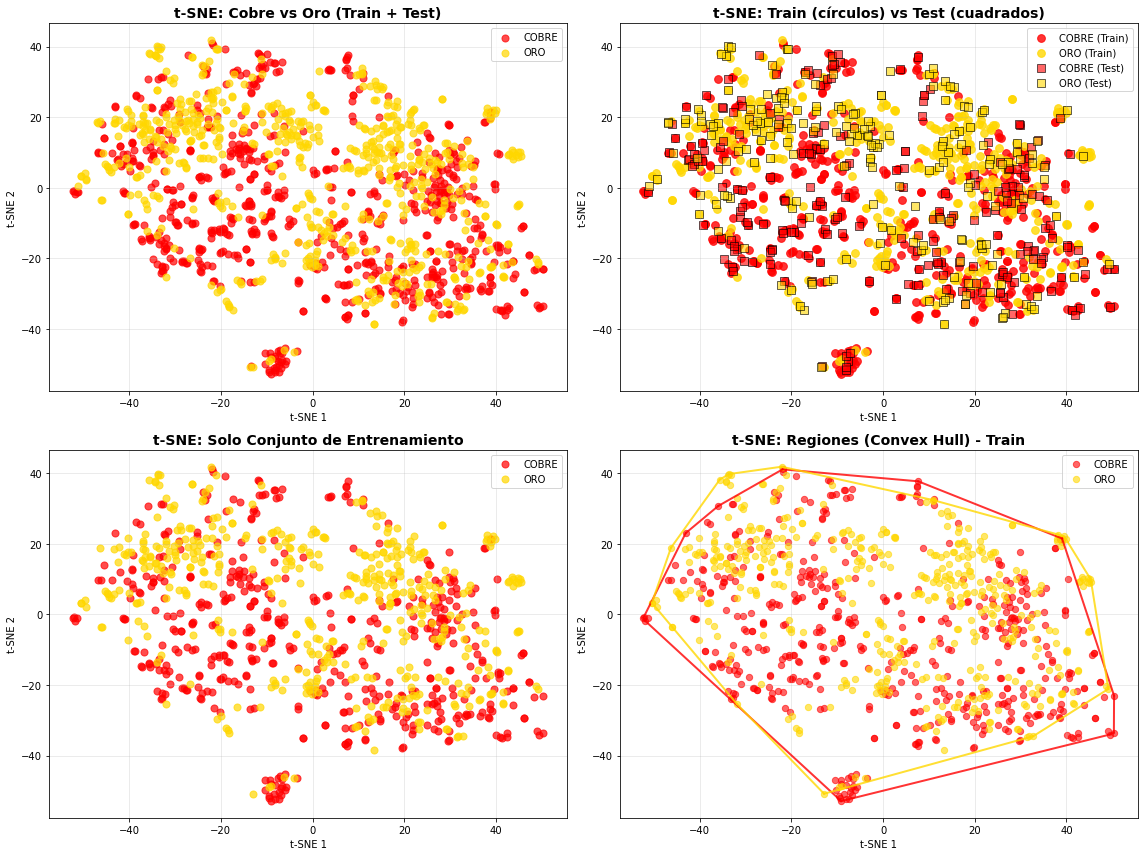


MÉTRICAS DE CALIDAD t-SNE - COBRE vs ORO
t-SNE - Conjunto de Entrenamiento (Cobre vs Oro):
  • Silhouette Score: 0.0321
  • Calinski-Harabasz Score: 26.7893
  • Interpretación: Alto solapamiento entre Cobre y Oro

Análisis de clusters (t-SNE - Train):
  • COBRE: 497 muestras
    Centroide: [0.456, -6.992]
    Desviación: [25.478, 20.718]
  • ORO: 453 muestras
    Centroide: [1.239, 3.862]
    Desviación: [25.582, 18.835]
  • Distancia entre centroides: 10.882

GUARDANDO RESULTADOS t-SNE - COBRE Y ORO
✓ Coordenadas t-SNE guardadas en: coordenadas_tsne_cobre_oro.csv
✓ Métricas t-SNE guardadas en: metricas_tsne_cobre_oro.csv

Resumen t-SNE - Cobre vs Oro:
• Muestras totales: 1358 (Train: 950, Test: 408)
• Silhouette Score: 0.0321
• Separación: Alto solapamiento entre Cobre y Oro

ANÁLISIS t-SNE COMPLETADO - COBRE Y ORO


In [42]:
#5
# =============================================================================
# ANÁLISIS t-SNE - SOLO COBRE Y ORO
# =============================================================================

print("\n" + "=" * 70)
print("ANÁLISIS t-SNE - FILTRADO PARA COBRE Y ORO")
print("=" * 70)

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.spatial import ConvexHull

# Usar los mismos datos filtrados que en UMAP
print(f"Usando datos filtrados para t-SNE:")
print(f"- Train: {X_train_selected.shape}")
print(f"- Test: {X_test_selected.shape}")

# Configurar t-SNE
tsne_reducer = TSNE(
    n_components=2,
    random_state=42,
    perplexity=min(30, train_size - 1),  # Ajustar perplexity según tamaño
    learning_rate=200,
    n_iter=1000
)

# Aplicar t-SNE a datos filtrados
print("Aplicando t-SNE a datos filtrados...")
X_tsne = tsne_reducer.fit_transform(X_combined_selected)
print("✓ t-SNE completado")

# =============================================================================
# VISUALIZACIONES t-SNE (COBRE Y ORO)
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Paleta de colores para Cobre y Oro
palette = {'COBRE': 'red', 'ORO': 'gold'}

# 1. t-SNE - Todos los datos combinados (Cobre y Oro)
for class_name in clases_deseadas:
    mask = y_combined_original == class_name
    color = palette[class_name]
    axes[0, 0].scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        color=color,
        label=class_name,
        alpha=0.7,
        s=50
    )
axes[0, 0].set_title('t-SNE: Cobre vs Oro (Train + Test)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('t-SNE 1')
axes[0, 0].set_ylabel('t-SNE 2')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# 2. t-SNE - Separado por Train/Test
# Train points
for class_name in clases_deseadas:
    mask = (y_train_filtered == class_name)
    color = palette[class_name]
    axes[0, 1].scatter(
        X_tsne[:train_size, 0][mask], X_tsne[:train_size, 1][mask],
        color=color,
        label=f'{class_name} (Train)',
        alpha=0.8,
        s=60,
        marker='o'
    )

# Test points
for class_name in clases_deseadas:
    mask = (y_test_filtered == class_name)
    color = palette[class_name]
    axes[0, 1].scatter(
        X_tsne[train_size:, 0][mask], X_tsne[train_size:, 1][mask],
        color=color,
        label=f'{class_name} (Test)',
        alpha=0.6,
        s=70,
        marker='s',
        edgecolor='black',
        linewidth=1.0
    )

axes[0, 1].set_title('t-SNE: Train (círculos) vs Test (cuadrados)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('t-SNE 1')
axes[0, 1].set_ylabel('t-SNE 2')
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True, alpha=0.3)

# 3. t-SNE - Solo Train (para análisis de clusters)
for class_name in clases_deseadas:
    mask = (y_train_filtered == class_name)
    color = palette[class_name]
    axes[1, 0].scatter(
        X_tsne[:train_size, 0][mask], X_tsne[:train_size, 1][mask],
        color=color,
        label=class_name,
        alpha=0.7,
        s=50
    )
axes[1, 0].set_title('t-SNE: Solo Conjunto de Entrenamiento', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('t-SNE 1')
axes[1, 0].set_ylabel('t-SNE 2')
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(True, alpha=0.3)

# 4. t-SNE - Convex Hull para mostrar regiones
for class_name in clases_deseadas:
    mask = (y_train_filtered == class_name)
    if np.sum(mask) >= 3:  # Mínimo 3 puntos para convex hull
        points = X_tsne[:train_size][mask]
        hull = ConvexHull(points)
        color = palette[class_name]
        
        # Dibujar el convex hull
        for simplex in hull.simplices:
            axes[1, 1].plot(points[simplex, 0], points[simplex, 1], 
                           color=color, linewidth=2, alpha=0.8)
        
        # Dibujar puntos
        axes[1, 1].scatter(
            points[:, 0], points[:, 1],
            color=color,
            label=class_name,
            alpha=0.6,
            s=40
        )

axes[1, 1].set_title('t-SNE: Regiones (Convex Hull) - Train', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('t-SNE 1')
axes[1, 1].set_ylabel('t-SNE 2')
axes[1, 1].legend(loc='upper right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tsne_cobre_oro.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# MÉTRICAS t-SNE PARA COBRE Y ORO
# =============================================================================

print("\n" + "=" * 70)
print("MÉTRICAS DE CALIDAD t-SNE - COBRE vs ORO")
print("=" * 70)

# Calcular métricas para t-SNE (solo train filtrado)
silhouette_tsne = silhouette_score(X_tsne[:train_size], y_train_filtered_encoded)
calinski_tsne = calinski_harabasz_score(X_tsne[:train_size], y_train_filtered_encoded)

print(f"t-SNE - Conjunto de Entrenamiento (Cobre vs Oro):")
print(f"  • Silhouette Score: {silhouette_tsne:.4f}")
print(f"  • Calinski-Harabasz Score: {calinski_tsne:.4f}")

# Interpretación del Silhouette Score
if silhouette_tsne > 0.7:
    interpretation = "Separación excelente entre Cobre y Oro"
elif silhouette_tsne > 0.5:
    interpretation = "Buena separación entre Cobre y Oro"
elif silhouette_tsne > 0.25:
    interpretation = "Separación moderada, algo de solapamiento"
else:
    interpretation = "Alto solapamiento entre Cobre y Oro"

print(f"  • Interpretación: {interpretation}")

# =============================================================================
# ANÁLISIS ADICIONAL: DISTANCIAS ENTRE CLUSTERS
# =============================================================================

print(f"\nAnálisis de clusters (t-SNE - Train):")
for class_name in clases_deseadas:
    mask = (y_train_filtered == class_name)
    n_samples = np.sum(mask)
    if n_samples > 0:
        class_points = X_tsne[:train_size][mask]
        centroid = np.mean(class_points, axis=0)
        std = np.std(class_points, axis=0)
        print(f"  • {class_name}: {n_samples} muestras")
        print(f"    Centroide: [{centroid[0]:.3f}, {centroid[1]:.3f}]")
        print(f"    Desviación: [{std[0]:.3f}, {std[1]:.3f}]")

# Calcular distancia entre centroides
if len(clases_deseadas) == 2:
    mask_cobre = (y_train_filtered == clases_deseadas[0])
    mask_oro = (y_train_filtered == clases_deseadas[1])
    
    centroide_cobre = np.mean(X_tsne[:train_size][mask_cobre], axis=0)
    centroide_oro = np.mean(X_tsne[:train_size][mask_oro], axis=0)
    
    distancia_tsne = np.linalg.norm(centroide_cobre - centroide_oro)
    print(f"  • Distancia entre centroides: {distancia_tsne:.3f}")

# =============================================================================
# GUARDAR RESULTADOS t-SNE
# =============================================================================

print("\n" + "=" * 70)
print("GUARDANDO RESULTADOS t-SNE - COBRE Y ORO")
print("=" * 70)

# Crear DataFrame con las coordenadas t-SNE
tsne_coordinates = pd.DataFrame({
    'Dataset': ['train'] * train_size + ['test'] * test_size,
    'Clase_Original': y_combined_original,
    'Clase_Encoded': y_combined_encoded,
    'tSNE_1': X_tsne[:, 0],
    'tSNE_2': X_tsne[:, 1]
})

# Guardar coordenadas
tsne_coordinates.to_csv('coordenadas_tsne_cobre_oro.csv', index=False)
print("✓ Coordenadas t-SNE guardadas en: coordenadas_tsne_cobre_oro.csv")

# Guardar métricas
tsne_metrics = pd.DataFrame({
    'Metrica': ['Silhouette_Score', 'Calinski_Harabasz_Score', 'Distancia_Centroides'],
    'Valor': [silhouette_tsne, calinski_tsne, distancia_tsne],
    'Interpretacion': [interpretation, 'Mayor valor = mejor separación', 'Distancia entre clusters']
})

tsne_metrics.to_csv('metricas_tsne_cobre_oro.csv', index=False)
print("✓ Métricas t-SNE guardadas en: metricas_tsne_cobre_oro.csv")

print(f"\nResumen t-SNE - Cobre vs Oro:")
print(f"• Muestras totales: {len(X_combined_selected)} (Train: {train_size}, Test: {test_size})")
print(f"• Silhouette Score: {silhouette_tsne:.4f}")
print(f"• Separación: {interpretation}")

print("\n" + "=" * 70)
print("ANÁLISIS t-SNE COMPLETADO - COBRE Y ORO")
print("=" * 70)

In [43]:
#6
# =============================================================================
# ANÁLISIS DE SEPARACIÓN LINEAL vs NO LINEAL
# =============================================================================

print("\n" + "=" * 70)
print("ANÁLISIS: ¿SEPARACIÓN LINEAL O NO LINEAL?")
print("=" * 70)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from scipy.spatial import ConvexHull
import seaborn as sns

def analizar_separacion_lineal(X_embeddings, y, clases, metodo_nombre):
    """
    Analiza si la separación entre clases es lineal o no lineal
    """
    print(f"\n{'='*50}")
    print(f"ANÁLISIS PARA: {metodo_nombre}")
    print(f"{'='*50}")
    
    # 1. CLASIFICADOR LINEAL (Logistic Regression)
    lr_model = LogisticRegression(random_state=42, max_iter=1000)
    lr_model.fit(X_embeddings, y)
    y_pred_lr = lr_model.predict(X_embeddings)
    acc_lr = accuracy_score(y, y_pred_lr)
    
    # 2. CLASIFICADOR NO LINEAL (SVM con RBF)
    svm_model = SVC(kernel='rbf', random_state=42)
    svm_model.fit(X_embeddings, y)
    y_pred_svm = svm_model.predict(X_embeddings)
    acc_svm = accuracy_score(y, y_pred_svm)
    
    # 3. ANÁLISIS GEOMÉTRICO
    # Calcular solapamiento de convex hulls
    hulls = []
    areas = []
    for clase in np.unique(y):
        points = X_embeddings[y == clase]
        if len(points) >= 3:
            hull = ConvexHull(points)
            hulls.append(hull)
            areas.append(hull.volume)  # Área/volumen del convex hull
    
    # 4. DISTANCIA ENTRE CENTROIDES vs VARIABILIDAD INTRACLASE
    centroides = []
    varianzas = []
    for clase in np.unique(y):
        points = X_embeddings[y == clase]
        centroide = np.mean(points, axis=0)
        varianza = np.mean(np.var(points, axis=0))
        centroides.append(centroide)
        varianzas.append(varianza)
    
    distancia_centroides = np.linalg.norm(centroides[0] - centroides[1])
    varianza_promedio = np.mean(varianzas)
    ratio_separacion = distancia_centroides / varianza_promedio
    
    # 5. DETERMINAR TIPO DE SEPARACIÓN
    diferencia_precision = acc_svm - acc_lr
    es_lineal = diferencia_precision < 0.1  # Umbral ajustable
    
    print(f"Resultados:")
    print(f"  • Precisión Regresión Logística: {acc_lr:.4f}")
    print(f"  • Precisión SVM RBF: {acc_svm:.4f}")
    print(f"  • Diferencia: {diferencia_precision:.4f}")
    print(f"  • Distancia entre centroides: {distancia_centroides:.4f}")
    print(f"  • Variabilidad intra-clase promedio: {varianza_promedio:.4f}")
    print(f"  • Ratio separación: {ratio_separacion:.4f}")
    
    if es_lineal:
        print(f"  • CONCLUSIÓN: SEPARACIÓN PREDOMINANTEMENTE LINEAL")
        if ratio_separacion > 3:
            print(f"  • Las clases están BIEN SEPARADAS linealmente")
        else:
            print(f"  • Las clases están DÉBILMENTE SEPARADAS linealmente")
    else:
        print(f"  • CONCLUSIÓN: SEPARACIÓN NO LINEAL")
        if diferencia_precision > 0.2:
            print(f"  • SEPARACIÓN FUERTEMENTE NO LINEAL")
        else:
            print(f"  • SEPARACIÓN MODERADAMENTE NO LINEAL")
    
    return {
        'metodo': metodo_nombre,
        'precision_lineal': acc_lr,
        'precision_no_lineal': acc_svm,
        'diferencia': diferencia_precision,
        'distancia_centroides': distancia_centroides,
        'ratio_separacion': ratio_separacion,
        'es_lineal': es_lineal
    }

# Aplicar análisis a UMAP y t-SNE
resultados = []

# Para UMAP (solo datos de entrenamiento)
print("\nAnalizando separación en espacio UMAP...")
resultado_umap = analizar_separacion_lineal(
    X_umap[:train_size], 
    y_train_filtered_encoded, 
    clases_deseadas,
    "UMAP"
)
resultados.append(resultado_umap)

# Para t-SNE (solo datos de entrenamiento)
print("\nAnalizando separación en espacio t-SNE...")
resultado_tsne = analizar_separacion_lineal(
    X_tsne[:train_size], 
    y_train_filtered_encoded, 
    clases_deseadas,
    "t-SNE"
)
resultados.append(resultado_tsne)


ANÁLISIS: ¿SEPARACIÓN LINEAL O NO LINEAL?

Analizando separación en espacio UMAP...

ANÁLISIS PARA: UMAP
Resultados:
  • Precisión Regresión Logística: 0.6200
  • Precisión SVM RBF: 0.6674
  • Diferencia: 0.0474
  • Distancia entre centroides: 1.3565
  • Variabilidad intra-clase promedio: 5.0756
  • Ratio separación: 0.2673
  • CONCLUSIÓN: SEPARACIÓN PREDOMINANTEMENTE LINEAL
  • Las clases están DÉBILMENTE SEPARADAS linealmente

Analizando separación en espacio t-SNE...

ANÁLISIS PARA: t-SNE
Resultados:
  • Precisión Regresión Logística: 0.6442
  • Precisión SVM RBF: 0.6684
  • Diferencia: 0.0242
  • Distancia entre centroides: 10.8820
  • Variabilidad intra-clase promedio: 521.8855
  • Ratio separación: 0.0209
  • CONCLUSIÓN: SEPARACIÓN PREDOMINANTEMENTE LINEAL
  • Las clases están DÉBILMENTE SEPARADAS linealmente


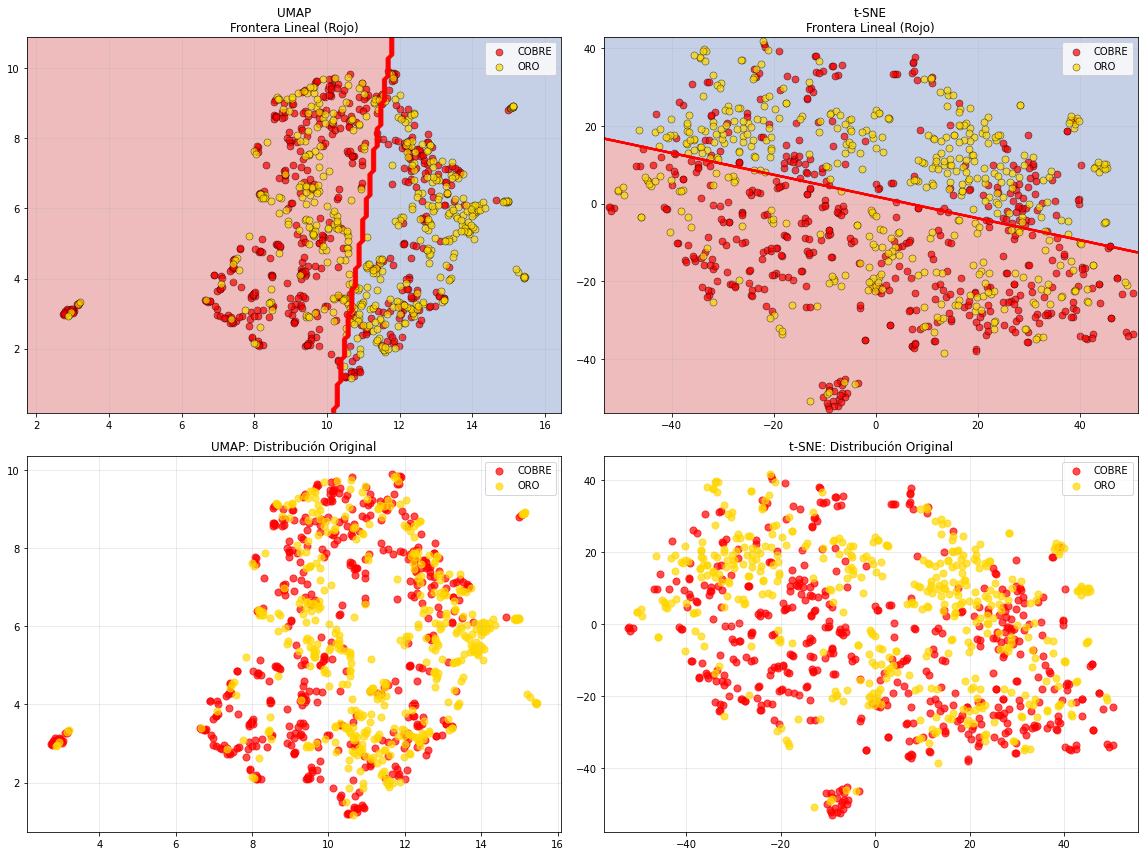

In [44]:
#7

# =============================================================================
# VISUALIZACIÓN DE FRONTERAS DE DECISIÓN
# =============================================================================

def visualizar_fronteras_decision(X_embeddings, y, clases, metodo_nombre, ax):
    """
    Visualiza las fronteras de decisión de clasificadores lineales y no lineales
    """
    # Crear mesh grid para visualización
    x_min, x_max = X_embeddings[:, 0].min() - 1, X_embeddings[:, 0].max() + 1
    y_min, y_max = X_embeddings[:, 1].min() - 1, X_embeddings[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    # Entrenar modelos
    lr_model = LogisticRegression(random_state=42, max_iter=1000)
    lr_model.fit(X_embeddings, y)
    
    svm_model = SVC(kernel='rbf', random_state=42)
    svm_model.fit(X_embeddings, y)
    
    # Predecir en mesh grid
    Z_lr = lr_model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z_svm = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
    
    Z_lr = Z_lr.reshape(xx.shape)
    Z_svm = Z_svm.reshape(xx.shape)
    
    # Plot fronteras
    ax.contourf(xx, yy, Z_lr, alpha=0.3, cmap='RdYlBu')
    ax.contour(xx, yy, Z_lr, colors='red', linewidths=2, alpha=0.8)
    
    # Plot puntos
    for i, clase in enumerate(np.unique(y)):
        mask = y == clase
        color = 'red' if i == 0 else 'gold'
        ax.scatter(X_embeddings[mask, 0], X_embeddings[mask, 1],
                  color=color, label=clases[i], alpha=0.7, s=50,
                  edgecolors='black', linewidth=0.5)
    
    ax.set_title(f'{metodo_nombre}\nFrontera Lineal (Rojo)', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

# Crear visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# UMAP - Fronteras de decisión
visualizar_fronteras_decision(
    X_umap[:train_size], 
    y_train_filtered_encoded, 
    clases_deseadas,
    "UMAP", 
    axes[0, 0]
)

# t-SNE - Fronteras de decisión
visualizar_fronteras_decision(
    X_tsne[:train_size], 
    y_train_filtered_encoded, 
    clases_deseadas,
    "t-SNE", 
    axes[0, 1]
)

# UMAP - Puntos originales
for i, clase in enumerate(np.unique(y_train_filtered_encoded)):
    mask = y_train_filtered_encoded == clase
    color = 'red' if i == 0 else 'gold'
    axes[1, 0].scatter(X_umap[:train_size, 0][mask], X_umap[:train_size, 1][mask],
                      color=color, label=clases_deseadas[i], alpha=0.7, s=50)
axes[1, 0].set_title('UMAP: Distribución Original', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# t-SNE - Puntos originales
for i, clase in enumerate(np.unique(y_train_filtered_encoded)):
    mask = y_train_filtered_encoded == clase
    color = 'red' if i == 0 else 'gold'
    axes[1, 1].scatter(X_tsne[:train_size, 0][mask], X_tsne[:train_size, 1][mask],
                      color=color, label=clases_deseadas[i], alpha=0.7, s=50)
axes[1, 1].set_title('t-SNE: Distribución Original', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analisis_linealidad.png', dpi=300, bbox_inches='tight')
plt.show()

In [45]:
# =============================================================================
# MÉTRICAS AVANZADAS DE SEPARACIÓN
# =============================================================================

def metricas_avanzadas_separacion(X_embeddings, y, metodo_nombre):
    """
    Calcula métricas avanzadas para determinar el tipo de separación
    """
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
    
    print(f"\n{'='*50}")
    print(f"MÉTRICAS AVANZADAS: {metodo_nombre}")
    print(f"{'='*50}")
    
    # 1. COMPARACIÓN LDA vs QDA
    lda = LinearDiscriminantAnalysis()
    qda = QuadraticDiscriminantAnalysis()
    
    # Validación cruzada simple
    from sklearn.model_selection import cross_val_score
    lda_scores = cross_val_score(lda, X_embeddings, y, cv=5)
    qda_scores = cross_val_score(qda, X_embeddings, y, cv=5)
    
    lda_mean = lda_scores.mean()
    qda_mean = qda_scores.mean()
    
    # 2. K-NN con diferentes k (linealidad local vs global)
    k1_scores = cross_val_score(KNeighborsClassifier(n_neighbors=1), X_embeddings, y, cv=5)
    k10_scores = cross_val_score(KNeighborsClassifier(n_neighbors=10), X_embeddings, y, cv=5)
    
    k1_mean = k1_scores.mean()
    k10_mean = k10_scores.mean()
    
    # 3. ANÁLISIS DE SOLAPAMIENTO
    from scipy.spatial.distance import mahalanobis
    from scipy.linalg import inv
    
    # Calcular matriz de covarianza pooled
    cov_pooled = np.cov(X_embeddings.T)
    
    # Distancia de Mahalanobis entre clases
    centroides = []
    for clase in np.unique(y):
        points = X_embeddings[y == clase]
        centroides.append(np.mean(points, axis=0))
    
    try:
        dist_mahalanobis = mahalanobis(centroides[0], centroides[1], inv(cov_pooled))
    except:
        dist_mahalanobis = np.linalg.norm(centroides[0] - centroides[1])
    
    print(f"LDA (lineal) - Precisión CV: {lda_mean:.4f}")
    print(f"QDA (no lineal) - Precisión CV: {qda_mean:.4f}")
    print(f"K-NN (k=1) - Precisión CV: {k1_mean:.4f}")
    print(f"K-NN (k=10) - Precisión CV: {k10_mean:.4f}")
    print(f"Distancia Mahalanobis: {dist_mahalanobis:.4f}")
    
    # CRITERIOS DE DECISIÓN
    criterios = []
    
    # Criterio 1: LDA vs QDA
    if qda_mean - lda_mean > 0.05:
        criterios.append("NO LINEAL (QDA > LDA)")
    else:
        criterios.append("LINEAL (LDA ≈ QDA)")
    
    # Criterio 2: K-NN local vs global
    if k1_mean - k10_mean > 0.05:
        criterios.append("NO LINEAL (estructura local)")
    else:
        criterios.append("LINEAL (estructura global)")
    
    # Criterio 3: Distancia Mahalanobis
    if dist_mahalanobis > 3:
        criterios.append("BIEN SEPARADAS")
    else:
        criterios.append("SOLAPADAS")
    
    print(f"\nCONCLUSIÓN: {', '.join(criterios)}")
    
    return {
        'lda_score': lda_mean,
        'qda_score': qda_mean,
        'knn1_score': k1_mean,
        'knn10_score': k10_mean,
        'dist_mahalanobis': dist_mahalanobis,
        'criterios': criterios
    }

# Aplicar métricas avanzadas
print("\n" + "=" * 70)
print("ANÁLISIS AVANZADO DE LINEALIDAD")
print("=" * 70)

metricas_umap = metricas_avanzadas_separacion(
    X_umap[:train_size], 
    y_train_filtered_encoded, 
    "UMAP"
)

metricas_tsne = metricas_avanzadas_separacion(
    X_tsne[:train_size], 
    y_train_filtered_encoded, 
    "t-SNE"
)


ANÁLISIS AVANZADO DE LINEALIDAD

MÉTRICAS AVANZADAS: UMAP
LDA (lineal) - Precisión CV: 0.6116
QDA (no lineal) - Precisión CV: 0.6368
K-NN (k=1) - Precisión CV: 0.6874
K-NN (k=10) - Precisión CV: 0.6821
Distancia Mahalanobis: 0.5961

CONCLUSIÓN: LINEAL (LDA ≈ QDA), LINEAL (estructura global), SOLAPADAS

MÉTRICAS AVANZADAS: t-SNE
LDA (lineal) - Precisión CV: 0.6442
QDA (no lineal) - Precisión CV: 0.6295
K-NN (k=1) - Precisión CV: 0.7579
K-NN (k=10) - Precisión CV: 0.7042
Distancia Mahalanobis: 0.5617

CONCLUSIÓN: LINEAL (LDA ≈ QDA), NO LINEAL (estructura local), SOLAPADAS


In [46]:
# =============================================================================
# ANÁLISIS PROFUNDO DEL SOLAPAMIENTO (CÓDIGO CORREGIDO)
# =============================================================================

print("\n" + "=" * 70)
print("ANÁLISIS PROFUNDO: SOLAPAMIENTO ENTRE COBRE Y ORO")
print("=" * 70)

def analizar_solapamiento_profundo(X_embeddings, y, clases, metodo_nombre):
    """
    Análisis detallado del solapamiento entre clases - CORREGIDO
    """
    from scipy.stats import gaussian_kde
    
    print(f"\n{metodo_nombre} - ANÁLISIS DE SOLAPAMIENTO:")
    print("-" * 50)
    
    # Verificar que hay datos en ambas clases
    unique_classes, counts = np.unique(y, return_counts=True)
    
    if len(unique_classes) < 2:
        print(f"  ⚠️  SOLO UNA CLASE PRESENTE: {clases[unique_classes[0]]}")
        print(f"  • No se puede calcular solapamiento con una sola clase")
        return 100.0, 0.0  # 100% de solapamiento (no hay separación posible)
    
    # Separar puntos por clase
    puntos_clase_0 = X_embeddings[y == 0]
    puntos_clase_1 = X_embeddings[y == 1]
    
    print(f"  • Muestras clase {clases[0]}: {len(puntos_clase_0)}")
    print(f"  • Muestras clase {clases[1]}: {len(puntos_clase_1)}")
    
    # Verificar que hay suficientes puntos en cada clase
    if len(puntos_clase_0) < 2 or len(puntos_clase_1) < 2:
        print(f"  ⚠️  CLASES CON MUY POCAS MUESTRAS")
        print(f"  • No se puede calcular solapamiento confiable")
        return 100.0, 0.0
    
    # 1. ANÁLISIS DE DENSIDAD EN LA LÍNEA ENTRE CENTROIDES
    centroide_0 = np.mean(puntos_clase_0, axis=0)
    centroide_1 = np.mean(puntos_clase_1, axis=0)
    
    # Vector dirección entre centroides
    vector_direccion = centroide_1 - centroide_0
    norm_vector = np.linalg.norm(vector_direccion)
    
    if norm_vector < 1e-10:  # Evitar división por cero
        print(f"  ⚠️  CENTROIDES COINCIDEN")
        print(f"  • Solapamiento completo")
        return 100.0, 0.0
    
    vector_direccion = vector_direccion / norm_vector
    
    # Proyectar puntos en la línea entre centroides
    proyecciones_0 = np.dot(puntos_clase_0 - centroide_0, vector_direccion)
    proyecciones_1 = np.dot(puntos_clase_1 - centroide_0, vector_direccion)
    
    # 2. CALCULAR SOLAPAMIENTO EN PROYECCIONES
    min_val = min(np.min(proyecciones_0), np.min(proyecciones_1))
    max_val = max(np.max(proyecciones_0), np.max(proyecciones_1))
    
    # Verificar que hay rango válido
    if max_val - min_val < 1e-10:
        print(f"  ⚠️  NO HAY RANGO EN PROYECCIONES")
        print(f"  • Todos los puntos están en la misma posición")
        return 100.0, 0.0
    
    # Estimación de densidad
    try:
        kde_0 = gaussian_kde(proyecciones_0)
        kde_1 = gaussian_kde(proyecciones_1)
        
        x_vals = np.linspace(min_val, max_val, 100)
        dens_0 = kde_0(x_vals)
        dens_1 = kde_1(x_vals)
        
        # Normalizar densidades
        dens_0 = dens_0 / np.trapz(dens_0, x_vals)
        dens_1 = dens_1 / np.trapz(dens_1, x_vals)
        
        # Calcular área de solapamiento
        area_solapamiento = np.trapz(np.minimum(dens_0, dens_1), x_vals)
        porcentaje_solapamiento = area_solapamiento * 100
        
    except Exception as e:
        # Método alternativo: usar histogramas
        print(f"  • KDE falló, usando método alternativo: {e}")
        try:
            hist_0, bins = np.histogram(proyecciones_0, bins=20, density=True)
            hist_1, _ = np.histogram(proyecciones_1, bins=bins, density=True)
            
            # Normalizar histogramas
            hist_0 = hist_0 / np.sum(hist_0)
            hist_1 = hist_1 / np.sum(hist_1)
            
            area_solapamiento = np.sum(np.minimum(hist_0, hist_1)) * (bins[1] - bins[0])
            porcentaje_solapamiento = min(area_solapamiento * 100, 100)
        except:
            # Método simple basado en distancia
            distancia = np.linalg.norm(centroide_1 - centroide_0)
            var_promedio = (np.var(proyecciones_0) + np.var(proyecciones_1)) / 2
            ratio = distancia / (np.sqrt(var_promedio) + 1e-10)
            porcentaje_solapamiento = max(0, 100 - (ratio * 20))  # Estimación aproximada
    
    # 3. ANÁLISIS DE REGIONES DE DECISIÓN
    try:
        from sklearn.linear_model import LogisticRegression
        lr = LogisticRegression(max_iter=1000)
        lr.fit(X_embeddings, y)
        
        # Probabilidades predichas
        y_proba = lr.predict_proba(X_embeddings)[:, 1]
        
        # Puntos cerca de la frontera (probabilidad entre 0.4 y 0.6)
        near_boundary = np.sum((y_proba > 0.4) & (y_proba < 0.6))
        porcentaje_frontera = (near_boundary / len(y)) * 100
        
    except:
        porcentaje_frontera = 50.0  # Valor por defecto si falla
    
    print(f"  • Porcentaje de solapamiento: {porcentaje_solapamiento:.1f}%")
    print(f"  • Puntos cerca de la frontera: {porcentaje_frontera:.1f}%")
    print(f"  • Distancia entre centroides: {np.linalg.norm(centroide_1 - centroide_0):.4f}")
    
    # Interpretación
    if porcentaje_solapamiento > 80:
        print(f"  → SOLAPAMIENTO MUY ALTO (>80%) - Separación casi imposible")
    elif porcentaje_solapamiento > 60:
        print(f"  → SOLAPAMIENTO ALTO (60-80%) - Separación muy difícil")
    elif porcentaje_solapamiento > 40:
        print(f"  → SOLAPAMIENTO MODERADO (40-60%) - Separación desafiante")
    elif porcentaje_solapamiento > 20:
        print(f"  → SOLAPAMIENTO BAJO (20-40%) - Separación posible")
    else:
        print(f"  → SOLAPAMIENTO MUY BAJO (<20%) - Buena separación")
    
    return porcentaje_solapamiento, porcentaje_frontera

# Aplicar análisis de solapamiento CON VERIFICACIÓN PREVIA
print("ANALIZANDO SOLAPAMIENTO ENTRE CLASES...")

# Verificar distribución de clases antes de analizar
unique_train, counts_train = np.unique(y_train_filtered_encoded, return_counts=True)
print(f"\nDistribución en Train: {dict(zip(unique_train, counts_train))}")

if len(unique_train) < 2:
    print("❌ ERROR: Solo una clase presente en los datos de entrenamiento")
    print("   No se puede analizar solapamiento con una sola clase")
else:
    solap_umap, frontera_umap = analizar_solapamiento_profundo(
        X_umap[:train_size], y_train_filtered_encoded, clases_deseadas, "UMAP"
    )

    solap_tsne, frontera_tsne = analizar_solapamiento_profundo(
        X_tsne[:train_size], y_train_filtered_encoded, clases_deseadas, "t-SNE"
    )


ANÁLISIS PROFUNDO: SOLAPAMIENTO ENTRE COBRE Y ORO
ANALIZANDO SOLAPAMIENTO ENTRE CLASES...

Distribución en Train: {0: 497, 1: 453}

UMAP - ANÁLISIS DE SOLAPAMIENTO:
--------------------------------------------------
  • Muestras clase COBRE: 497
  • Muestras clase ORO: 453
  • Porcentaje de solapamiento: 79.1%
  • Puntos cerca de la frontera: 40.1%
  • Distancia entre centroides: 1.3565
  → SOLAPAMIENTO ALTO (60-80%) - Separación muy difícil

t-SNE - ANÁLISIS DE SOLAPAMIENTO:
--------------------------------------------------
  • Muestras clase COBRE: 497
  • Muestras clase ORO: 453
  • Porcentaje de solapamiento: 73.2%
  • Puntos cerca de la frontera: 44.4%
  • Distancia entre centroides: 10.8820
  → SOLAPAMIENTO ALTO (60-80%) - Separación muy difícil



COMPARACIÓN DE CLASIFICADORES - COBRE VS ORO

PREPARACIÓN DE DATOS

Verificación de codificación:
- Clases originales: ['COBRE', 'ORO']
- Clases codificadas: ['COBRE' 'ORO']
- Valores únicos en train: [0 1]
- Valores únicos en test: [0 1]
- Mapeo: {'COBRE': 0, 'ORO': 1}

Datos disponibles:
- X_train_selected: (950, 55)
- X_test_selected: (408, 55)
- y_train: 950 muestras
- y_test: 408 muestras

ENTRENANDO Y EVALUANDO MODELOS

Modelo: Logistic Regression
Accuracy Train: 0.7442
Accuracy Test:  0.7132
Accuracy CV:    0.7095 (± 0.0418)
Precision:      0.7132
Recall:         0.7132
F1-Score:       0.7127
ROC-AUC:        0.7733
Overfitting:    0.0310
Tiempo Train:   0.0312s
Tiempo Pred:    0.0000s

Classification Report:
              precision    recall  f1-score   support

       COBRE     0.7143    0.7512    0.7323       213
         ORO     0.7120    0.6718    0.6913       195

    accuracy                         0.7132       408
   macro avg     0.7131    0.7115    0.7118       408
we

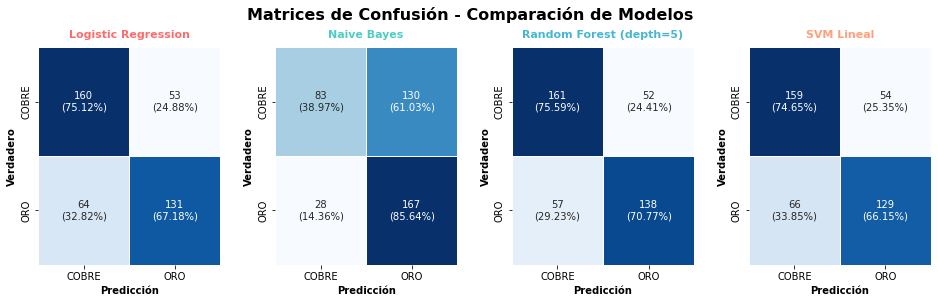


GENERANDO VISUALIZACIÓN 2: MÉTRICAS DE RENDIMIENTO
✓ Visualización 2 guardada: viz2_metricas_rendimiento.png


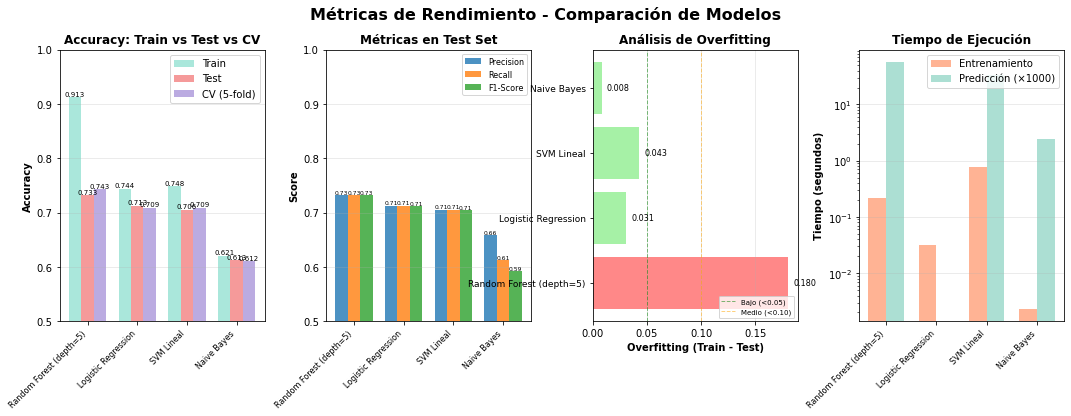


GENERANDO VISUALIZACIÓN 3: CURVAS ROC Y RANKING
✓ Visualización 3 guardada: viz3_roc_ranking.png


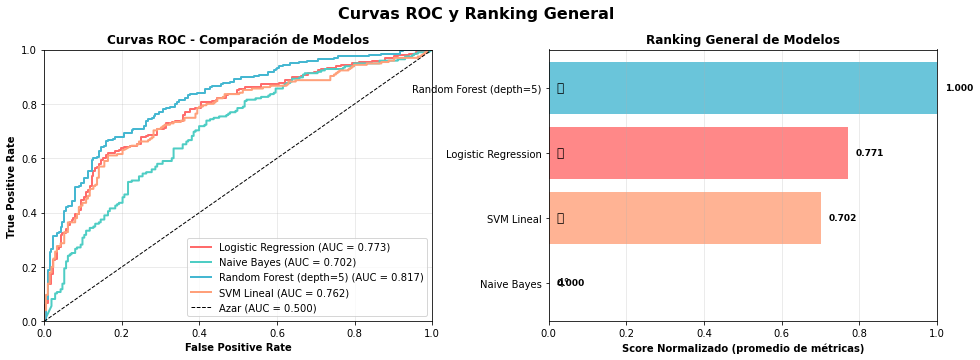


ANÁLISIS DETALLADO POR CLASE

Modelo: Logistic Regression

Clase: COBRE
  • Precision: 0.7143
  • Recall:    0.7512
  • F1-Score:  0.7323
  • TP: 160, FP: 64, FN: 53, TN: 131

Clase: ORO
  • Precision: 0.7120
  • Recall:    0.6718
  • F1-Score:  0.6913
  • TP: 131, FP: 53, FN: 64, TN: 160

Modelo: Naive Bayes

Clase: COBRE
  • Precision: 0.7477
  • Recall:    0.3897
  • F1-Score:  0.5123
  • TP: 83, FP: 28, FN: 130, TN: 167

Clase: ORO
  • Precision: 0.5623
  • Recall:    0.8564
  • F1-Score:  0.6789
  • TP: 167, FP: 130, FN: 28, TN: 83

Modelo: Random Forest (depth=5)

Clase: COBRE
  • Precision: 0.7385
  • Recall:    0.7559
  • F1-Score:  0.7471
  • TP: 161, FP: 57, FN: 52, TN: 138

Clase: ORO
  • Precision: 0.7263
  • Recall:    0.7077
  • F1-Score:  0.7169
  • TP: 138, FP: 52, FN: 57, TN: 161

Modelo: SVM Lineal

Clase: COBRE
  • Precision: 0.7067
  • Recall:    0.7465
  • F1-Score:  0.7260
  • TP: 159, FP: 66, FN: 54, TN: 129

Clase: ORO
  • Precision: 0.7049
  • Recall:    0.661

In [48]:
# =============================================================================
# COMPARACIÓN DE CLASIFICADORES: Cobre vs Oro (VISUALIZACIONES SEPARADAS)
# =============================================================================

print("\n" + "=" * 70)
print("COMPARACIÓN DE CLASIFICADORES - COBRE VS ORO")
print("=" * 70)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score
)
from sklearn.model_selection import cross_val_score, cross_validate
import time

# =============================================================================
# RE-CODIFICAR LAS CLASES FILTRADAS (SOLO COBRE Y ORO) → {0, 1}
# =============================================================================

print("\n" + "=" * 70)
print("PREPARACIÓN DE DATOS")
print("=" * 70)

# Crear un nuevo LabelEncoder SOLO para Cobre y Oro
le_filtered = LabelEncoder()
y_train_encoded_filtered = le_filtered.fit_transform(y_train_filtered)
y_test_encoded_filtered = le_filtered.transform(y_test_filtered)

print(f"\nVerificación de codificación:")
print(f"- Clases originales: {clases_deseadas}")
print(f"- Clases codificadas: {le_filtered.classes_}")
print(f"- Valores únicos en train: {np.unique(y_train_encoded_filtered)}")
print(f"- Valores únicos en test: {np.unique(y_test_encoded_filtered)}")
print(f"- Mapeo: {dict(zip(le_filtered.classes_, range(len(le_filtered.classes_))))}")

print(f"\nDatos disponibles:")
print(f"- X_train_selected: {X_train_selected.shape}")
print(f"- X_test_selected: {X_test_selected.shape}")
print(f"- y_train: {len(y_train_encoded_filtered)} muestras")
print(f"- y_test: {len(y_test_encoded_filtered)} muestras")

# =============================================================================
# DEFINIR MODELOS
# =============================================================================

modelos = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000,
        solver='lbfgs',
        class_weight='balanced'
    ),
    
    'Naive Bayes': GaussianNB(
        var_smoothing=1e-9
    ),
    
    'Random Forest (depth=5)': RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    
    'SVM Lineal': SVC(
        kernel='linear',
        random_state=42,
        class_weight='balanced',
        probability=True
    )
}

# =============================================================================
# ENTRENAMIENTO Y EVALUACIÓN
# =============================================================================

resultados = []
modelos_entrenados = {}
matrices_confusion = {}
predicciones = {}

print("\n" + "=" * 70)
print("ENTRENANDO Y EVALUANDO MODELOS")
print("=" * 70)

for nombre, modelo in modelos.items():
    print(f"\n{'='*50}")
    print(f"Modelo: {nombre}")
    print(f"{'='*50}")
    
    # Medir tiempo de entrenamiento
    inicio = time.time()
    modelo.fit(X_train_selected, y_train_encoded_filtered)
    tiempo_entrenamiento = time.time() - inicio
    
    # Predicciones
    inicio_pred = time.time()
    y_pred_train = modelo.predict(X_train_selected)
    y_pred_test = modelo.predict(X_test_selected)
    tiempo_prediccion = time.time() - inicio_pred
    
    # Probabilidades para ROC-AUC
    if hasattr(modelo, "predict_proba"):
        y_proba_test = modelo.predict_proba(X_test_selected)[:, 1]
    elif hasattr(modelo, "decision_function"):
        y_proba_test = modelo.decision_function(X_test_selected)
    else:
        y_proba_test = None
    
    # Métricas en TRAIN
    acc_train = accuracy_score(y_train_encoded_filtered, y_pred_train)
    
    # Métricas en TEST
    acc_test = accuracy_score(y_test_encoded_filtered, y_pred_test)
    precision_test = precision_score(y_test_encoded_filtered, y_pred_test, average='weighted')
    recall_test = recall_score(y_test_encoded_filtered, y_pred_test, average='weighted')
    f1_test = f1_score(y_test_encoded_filtered, y_pred_test, average='weighted')
    
    # ROC-AUC (ahora funcionará correctamente con {0, 1})
    if y_proba_test is not None:
        roc_auc_test = roc_auc_score(y_test_encoded_filtered, y_proba_test)
    else:
        roc_auc_test = np.nan
    
    # Cross-validation en TRAIN (5-fold)
    cv_scores = cross_val_score(
        modelo, 
        X_train_selected, 
        y_train_encoded_filtered, 
        cv=5, 
        scoring='accuracy'
    )
    acc_cv_mean = cv_scores.mean()
    acc_cv_std = cv_scores.std()
    
    # Matriz de confusión
    cm = confusion_matrix(y_test_encoded_filtered, y_pred_test)
    matrices_confusion[nombre] = cm
    
    # Guardar resultados
    resultados.append({
        'Modelo': nombre,
        'Accuracy Train': acc_train,
        'Accuracy Test': acc_test,
        'Accuracy CV (mean)': acc_cv_mean,
        'Accuracy CV (std)': acc_cv_std,
        'Precision Test': precision_test,
        'Recall Test': recall_test,
        'F1-Score Test': f1_test,
        'ROC-AUC Test': roc_auc_test,
        'Tiempo Entrenamiento (s)': tiempo_entrenamiento,
        'Tiempo Predicción (s)': tiempo_prediccion,
        'Overfitting': acc_train - acc_test
    })
    
    modelos_entrenados[nombre] = modelo
    predicciones[nombre] = {
        'y_pred_test': y_pred_test,
        'y_proba_test': y_proba_test
    }
    
    # Imprimir resultados
    print(f"Accuracy Train: {acc_train:.4f}")
    print(f"Accuracy Test:  {acc_test:.4f}")
    print(f"Accuracy CV:    {acc_cv_mean:.4f} (± {acc_cv_std:.4f})")
    print(f"Precision:      {precision_test:.4f}")
    print(f"Recall:         {recall_test:.4f}")
    print(f"F1-Score:       {f1_test:.4f}")
    if not np.isnan(roc_auc_test):
        print(f"ROC-AUC:        {roc_auc_test:.4f}")
    print(f"Overfitting:    {acc_train - acc_test:.4f}")
    print(f"Tiempo Train:   {tiempo_entrenamiento:.4f}s")
    print(f"Tiempo Pred:    {tiempo_prediccion:.4f}s")
    
    # Classification report detallado
    print(f"\nClassification Report:")
    print(classification_report(
        y_test_encoded_filtered, 
        y_pred_test,
        target_names=le_filtered.classes_,
        digits=4
    ))

# =============================================================================
# TABLA COMPARATIVA
# =============================================================================

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('Accuracy Test', ascending=False)

print("\n" + "=" * 70)
print("TABLA COMPARATIVA DE MODELOS")
print("=" * 70)
print(df_resultados.to_string(index=False))

# Guardar resultados
df_resultados.to_csv('comparacion_modelos_cobre_oro.csv', index=False)
print("\n✓ Resultados guardados en: comparacion_modelos_cobre_oro.csv")

# =============================================================================
# VISUALIZACIÓN 1: MATRICES DE CONFUSIÓN
# =============================================================================

print("\n" + "=" * 70)
print("GENERANDO VISUALIZACIÓN 1: MATRICES DE CONFUSIÓN")
print("=" * 70)

# Paleta de colores para los modelos
colores_modelos = {
    'Logistic Regression': '#FF6B6B',
    'Naive Bayes': '#4ECDC4',
    'Random Forest (depth=5)': '#45B7D1',
    'SVM Lineal': '#FFA07A'
}

# Crear figura para matrices de confusión
fig1 = plt.figure(figsize=(16, 4))
fig1.suptitle('Matrices de Confusión - Comparación de Modelos', 
              fontsize=16, fontweight='bold', y=1.02)

# Crear grid para matrices
gs1 = fig1.add_gridspec(1, 4, hspace=0.3, wspace=0.3)

# Plotear matrices de confusión
for idx, (nombre, cm) in enumerate(matrices_confusion.items()):
    ax = fig1.add_subplot(gs1[0, idx])
    
    # Normalizar matriz
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Crear heatmap
    sns.heatmap(
        cm_norm, 
        annot=np.array([[f'{cm[i,j]}\n({cm_norm[i,j]:.2%})' 
                        for j in range(cm.shape[1])] 
                       for i in range(cm.shape[0])]),
        fmt='',
        cmap='Blues',
        xticklabels=le_filtered.classes_,
        yticklabels=le_filtered.classes_,
        cbar=False,
        ax=ax,
        linewidths=1,
        linecolor='white'
    )
    
    ax.set_title(nombre, fontweight='bold', fontsize=11, 
                color=colores_modelos[nombre], pad=10)
    ax.set_xlabel('Predicción', fontweight='bold')
    ax.set_ylabel('Verdadero', fontweight='bold')

plt.savefig('viz1_matrices_confusion.png', dpi=300, bbox_inches='tight')
print("✓ Visualización 1 guardada: viz1_matrices_confusion.png")
plt.show()

# =============================================================================
# VISUALIZACIÓN 2: MÉTRICAS DE RENDIMIENTO (FILA 2)
# =============================================================================

print("\n" + "=" * 70)
print("GENERANDO VISUALIZACIÓN 2: MÉTRICAS DE RENDIMIENTO")
print("=" * 70)

# Crear figura para métricas
fig2 = plt.figure(figsize=(18, 5))
fig2.suptitle('Métricas de Rendimiento - Comparación de Modelos', 
              fontsize=16, fontweight='bold', y=1.00)

# Crear grid para gráficos de métricas
gs2 = fig2.add_gridspec(1, 4, hspace=0.3, wspace=0.3)

# 2.1 - Accuracy (Train vs Test vs CV)
ax1 = fig2.add_subplot(gs2[0, 0])
x = np.arange(len(df_resultados))
width = 0.25

bars1 = ax1.bar(x - width, df_resultados['Accuracy Train'], width, 
                label='Train', alpha=0.8, color='#95E1D3')
bars2 = ax1.bar(x, df_resultados['Accuracy Test'], width, 
                label='Test', alpha=0.8, color='#F38181')
bars3 = ax1.bar(x + width, df_resultados['Accuracy CV (mean)'], width, 
                label='CV (5-fold)', alpha=0.8, color='#AA96DA')

ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Accuracy: Train vs Test vs CV', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(df_resultados['Modelo'], rotation=45, ha='right', fontsize=8)
ax1.legend()
ax1.set_ylim([0.5, 1.0])
ax1.grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=7)

# 2.2 - Métricas Test (Precision, Recall, F1)
ax2 = fig2.add_subplot(gs2[0, 1])
metricas = ['Precision Test', 'Recall Test', 'F1-Score Test']
x = np.arange(len(df_resultados))
width = 0.25

for i, metrica in enumerate(metricas):
    offset = (i - 1) * width
    bars = ax2.bar(x + offset, df_resultados[metrica], width,
                   label=metrica.replace(' Test', ''), alpha=0.8)
    
    # Añadir valores
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=6)

ax2.set_ylabel('Score', fontweight='bold')
ax2.set_title('Métricas en Test Set', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(df_resultados['Modelo'], rotation=45, ha='right', fontsize=8)
ax2.legend(fontsize=8)
ax2.set_ylim([0.5, 1.0])
ax2.grid(axis='y', alpha=0.3)

# 2.3 - Overfitting Analysis
ax3 = fig2.add_subplot(gs2[0, 2])
colores_overfitting = ['#90EE90' if x < 0.05 else '#FFD700' if x < 0.10 else '#FF6B6B' 
                       for x in df_resultados['Overfitting']]

bars = ax3.barh(range(len(df_resultados)), df_resultados['Overfitting'], 
                color=colores_overfitting, alpha=0.8)

ax3.set_yticks(range(len(df_resultados)))
ax3.set_yticklabels(df_resultados['Modelo'], fontsize=9)
ax3.set_xlabel('Overfitting (Train - Test)', fontweight='bold')
ax3.set_title('Análisis de Overfitting', fontweight='bold')
ax3.axvline(x=0.05, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Bajo (<0.05)')
ax3.axvline(x=0.10, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Medio (<0.10)')
ax3.legend(fontsize=7, loc='lower right')
ax3.grid(axis='x', alpha=0.3)

# Añadir valores
for bar, val in zip(bars, df_resultados['Overfitting']):
    ax3.text(val + 0.005 if val >= 0 else val - 0.005, 
            bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=8)

# 2.4 - Tiempo de Ejecución
ax4 = fig2.add_subplot(gs2[0, 3])
x = np.arange(len(modelos))
width = 0.35

bars1 = ax4.bar(x - width/2, df_resultados['Tiempo Entrenamiento (s)'], width, 
                label='Entrenamiento', alpha=0.8, color='#FFA07A')
bars2 = ax4.bar(x + width/2, df_resultados['Tiempo Predicción (s)'] * 1000, width, 
                label='Predicción (×1000)', alpha=0.8, color='#98D8C8')

ax4.set_ylabel('Tiempo (segundos)', fontweight='bold')
ax4.set_title('Tiempo de Ejecución', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(df_resultados['Modelo'], rotation=45, ha='right', fontsize=8)
ax4.legend()
ax4.set_yscale('log')
ax4.grid(axis='y', alpha=0.3)

plt.savefig('viz2_metricas_rendimiento.png', dpi=300, bbox_inches='tight')
print("✓ Visualización 2 guardada: viz2_metricas_rendimiento.png")
plt.show()

# =============================================================================
# VISUALIZACIÓN 3: CURVAS ROC Y RANKING (FILA 3)
# =============================================================================

print("\n" + "=" * 70)
print("GENERANDO VISUALIZACIÓN 3: CURVAS ROC Y RANKING")
print("=" * 70)

# Crear figura para ROC y ranking
fig3 = plt.figure(figsize=(16, 5))
fig3.suptitle('Curvas ROC y Ranking General', 
              fontsize=16, fontweight='bold', y=1.00)

# Crear grid
gs3 = fig3.add_gridspec(1, 2, hspace=0.3, wspace=0.3)

# 3.1 - Curvas ROC
ax1 = fig3.add_subplot(gs3[0, 0])

# Graficar curvas ROC para cada modelo 
for nombre in modelos.keys():
    if predicciones[nombre]['y_proba_test'] is not None:
        fpr, tpr, _ = roc_curve(
            y_test_encoded_filtered,
            predicciones[nombre]['y_proba_test']
        )
        roc_auc = auc(fpr, tpr)
        
        ax1.plot(
            fpr, tpr,
            label=f'{nombre} (AUC = {roc_auc:.3f})',
            linewidth=2,
            color=colores_modelos[nombre]
        )

# Línea diagonal (clasificador aleatorio)
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Azar (AUC = 0.500)')

ax1.set_xlabel('False Positive Rate', fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontweight='bold')
ax1.set_title('Curvas ROC - Comparación de Modelos', fontweight='bold', fontsize=12)
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

# 3.2 - Ranking de Modelos
ax2 = fig3.add_subplot(gs3[0, 1])

# Crear ranking basado en múltiples criterios
criterios = ['Accuracy Test', 'F1-Score Test', 'ROC-AUC Test']
df_ranking = df_resultados[['Modelo'] + criterios].copy()

# Normalizar cada criterio (0-1)
for criterio in criterios:
    if df_ranking[criterio].notna().any():
        min_val = df_ranking[criterio].min()
        max_val = df_ranking[criterio].max()
        if max_val > min_val:
            df_ranking[f'{criterio}_norm'] = (df_ranking[criterio] - min_val) / (max_val - min_val)
        else:
            df_ranking[f'{criterio}_norm'] = 0.5

# Calcular score promedio
criterios_norm = [f'{c}_norm' for c in criterios if f'{c}_norm' in df_ranking.columns]
df_ranking['Score Final'] = df_ranking[criterios_norm].mean(axis=1)
df_ranking = df_ranking.sort_values('Score Final', ascending=True)

# Plot horizontal bar
colores_ranking = [colores_modelos[modelo] for modelo in df_ranking['Modelo']]
bars = ax2.barh(range(len(df_ranking)), df_ranking['Score Final'], 
                color=colores_ranking, alpha=0.8)

ax2.set_yticks(range(len(df_ranking)))
ax2.set_yticklabels(df_ranking['Modelo'], fontsize=10)
ax2.set_xlabel('Score Normalizado (promedio de métricas)', fontweight='bold')
ax2.set_title('Ranking General de Modelos', fontweight='bold', fontsize=12)
ax2.set_xlim([0, 1])
ax2.grid(axis='x', alpha=0.3)

# Añadir valores y posición
for i, (bar, score, modelo) in enumerate(zip(bars, df_ranking['Score Final'], df_ranking['Modelo'])):
    # Score
    ax2.text(score + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{score:.3f}',
            va='center', ha='left', fontsize=9, fontweight='bold')
    # Posición
    posicion = len(df_ranking) - i
    emoji = '🥇' if posicion == 1 else '🥈' if posicion == 2 else '🥉' if posicion == 3 else f'{posicion}°'
    ax2.text(0.02, bar.get_y() + bar.get_height()/2, 
            emoji,
            va='center', ha='left', fontsize=12)

plt.savefig('viz3_roc_ranking.png', dpi=300, bbox_inches='tight')
print("✓ Visualización 3 guardada: viz3_roc_ranking.png")
plt.show()

# =============================================================================
# ANÁLISIS DETALLADO POR CLASE
# =============================================================================

print("\n" + "=" * 70)
print("ANÁLISIS DETALLADO POR CLASE")
print("=" * 70)

for nombre in modelos.keys():
    print(f"\n{'='*50}")
    print(f"Modelo: {nombre}")
    print(f"{'='*50}")
    
    y_pred = predicciones[nombre]['y_pred_test']
    
    # Métricas por clase
    for i, clase in enumerate(le_filtered.classes_):
        mask_true = y_test_encoded_filtered == i
        mask_pred = y_pred == i
        
        # True Positives, False Positives, False Negatives
        tp = np.sum(mask_true & mask_pred)
        fp = np.sum(~mask_true & mask_pred)
        fn = np.sum(mask_true & ~mask_pred)
        tn = np.sum(~mask_true & ~mask_pred)
        
        # Métricas
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        print(f"\nClase: {clase}")
        print(f"  • Precision: {precision:.4f}")
        print(f"  • Recall:    {recall:.4f}")
        print(f"  • F1-Score:  {f1:.4f}")
        print(f"  • TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")

# =============================================================================
# ANÁLISIS DE ERRORES
# =============================================================================

print("\n" + "=" * 70)
print("ANÁLISIS DE ERRORES - MUESTRAS MAL CLASIFICADAS")
print("=" * 70)

# Usar el mejor modelo (según accuracy test)
mejor_modelo_nombre = df_resultados.iloc[0]['Modelo']
mejor_modelo = modelos_entrenados[mejor_modelo_nombre]
y_pred_mejor = predicciones[mejor_modelo_nombre]['y_pred_test']
y_proba_mejor = predicciones[mejor_modelo_nombre]['y_proba_test']

print(f"\nAnalizando errores del mejor modelo: {mejor_modelo_nombre}")

# Identificar errores
errores_mask = y_pred_mejor != y_test_encoded_filtered
n_errores = np.sum(errores_mask)

print(f"\nTotal de errores: {n_errores} / {len(y_test_encoded_filtered)} ({n_errores/len(y_test_encoded_filtered)*100:.1f}%)")

# Análisis de errores por tipo
errores_cobre_como_oro = np.sum((y_test_encoded_filtered == 0) & (y_pred_mejor == 1))
errores_oro_como_cobre = np.sum((y_test_encoded_filtered == 1) & (y_pred_mejor == 0))

print(f"\nTipos de error:")
print(f"  • {le_filtered.classes_[0]} clasificado como {le_filtered.classes_[1]}: {errores_cobre_como_oro} ({errores_cobre_como_oro/n_errores*100:.1f}%)")
print(f"  • {le_filtered.classes_[1]} clasificado como {le_filtered.classes_[0]}: {errores_oro_como_cobre} ({errores_oro_como_cobre/n_errores*100:.1f}%)")

# Analizar confianza en predicciones incorrectas
if y_proba_mejor is not None:
    confianza_predicciones = np.abs(y_proba_mejor - 0.5) * 2
    
    confianza_correctas = confianza_predicciones[~errores_mask]
    confianza_incorrectas = confianza_predicciones[errores_mask]
    
    print(f"\nAnálisis de confianza:")
    print(f"  • Confianza promedio (correctas):   {confianza_correctas.mean():.4f}")
    print(f"  • Confianza promedio (incorrectas): {confianza_incorrectas.mean():.4f}")
    
    umbral_baja_confianza = 0.3
    n_baja_confianza = np.sum(confianza_predicciones < umbral_baja_confianza)
    print(f"  • Predicciones con baja confianza (<{umbral_baja_confianza}): {n_baja_confianza} ({n_baja_confianza/len(confianza_predicciones)*100:.1f}%)")

# =============================================================================
# GUARDAR MODELOS ENTRENADOS
# =============================================================================

import pickle

print("\n" + "=" * 70)
print("GUARDANDO MODELOS ENTRENADOS")
print("=" * 70)

for nombre, modelo in modelos_entrenados.items():
    filename = nombre.replace(' ', '_').replace('(', '').replace(')', '').replace('=', '') + '.pkl'
    
    with open(filename, 'wb') as f:
        pickle.dump(modelo, f)
    
    print(f"✓ {nombre} guardado en: {filename}")

# Guardar también el LabelEncoder filtrado
with open('label_encoder_filtered.pkl', 'wb') as f:
    pickle.dump(le_filtered, f)
print(f"✓ LabelEncoder guardado en: label_encoder_filtered.pkl")

print("\n" + "=" * 70)
print("ANÁLISIS COMPLETADO")
print("=" * 70)
print(f"\nMejor modelo: {mejor_modelo_nombre}")
print(f"Accuracy Test: {df_resultados.iloc[0]['Accuracy Test']:.4f}")
print(f"F1-Score Test: {df_resultados.iloc[0]['F1-Score Test']:.4f}")

print("\n" + "=" * 70)
print("VISUALIZACIONES GENERADAS:")
print("=" * 70)
print("✓ viz1_matrices_confusion.png - Matrices de Confusión")
print("✓ viz2_metricas_rendimiento.png - Métricas de Rendimiento")
print("✓ viz3_roc_ranking.png - Curvas ROC y Ranking")
print("=" * 70)

# EVALUACION MODELOS BASE


FASE 2: OPTIMIZACIÓN DE HIPERPARÁMETROS - RANDOM FOREST

CARGANDO DATOS DE FASE 1
✓ Datos cargados correctamente
  • Modelos base evaluados: 4
  • Training samples: 950
  • Test samples: 408

📊 Random Forest Base (depth=5):
  • Accuracy Test: 0.7328
  • F1-Score Test: 0.7327
  • Confianza:     0.2562
  • Overfitting:   0.1798

CONFIGURACIÓN DE GRID SEARCH

Espacio de búsqueda:
  • max_depth: [5, 7, 10, 15, None]
  • min_samples_split: [5, 10, 20]
  • min_samples_leaf: [2, 5, 10]
  • n_estimators: [100, 200, 300]
  • max_features: ['sqrt', 'log2', 0.5]

📈 Total de combinaciones: 405
   Tiempo estimado: 3.4 - 10.1 minutos

EJECUTANDO GRID SEARCH

⏳ Esto puede tomar varios minutos... Por favor espera.
   (Se mostrarán actualizaciones de progreso)

Fitting 5 folds for each of 405 candidates, totalling 2025 fits

✓ Grid Search completado en 15.0 minutos (898.3 segundos)

MEJORES HIPERPARÁMETROS ENCONTRADOS

🏆 Mejores parámetros:
  • max_depth: 10
  • max_features: 0.5
  • min_samples_leaf:

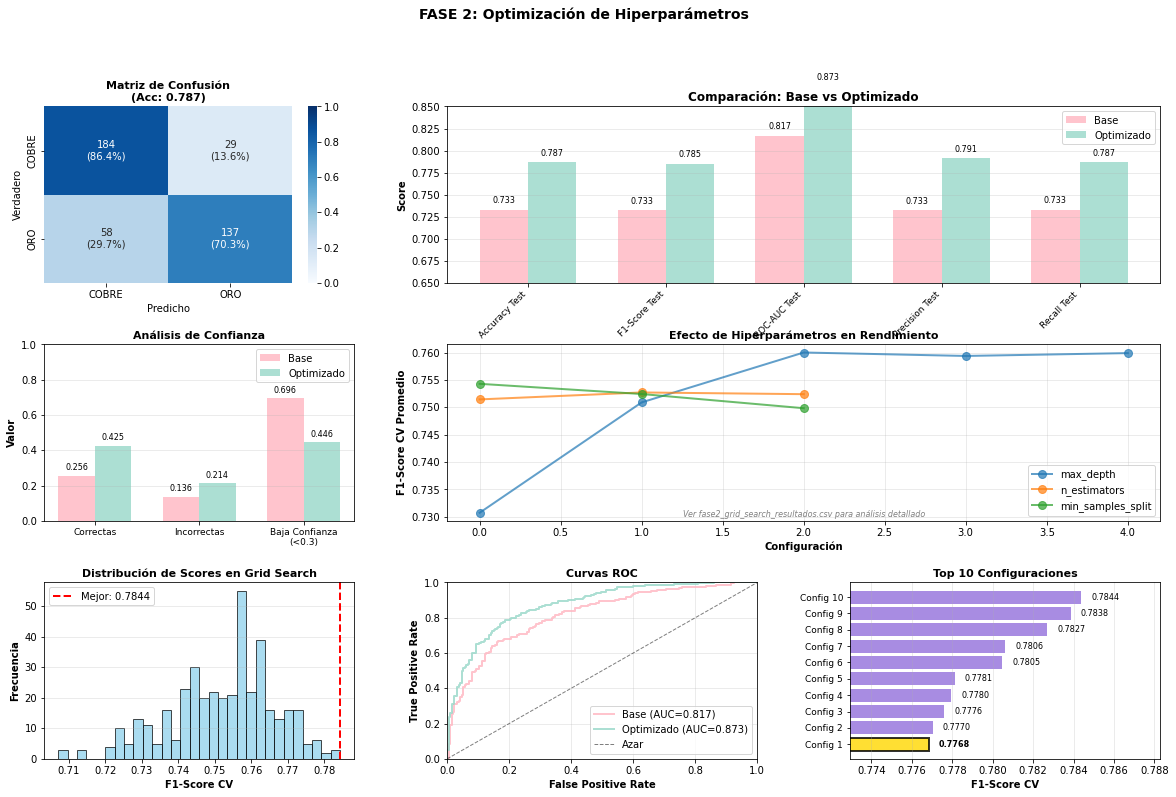


✓ Visualización guardada: fase2_optimizacion_hiperparametros.png

GUARDANDO MODELO OPTIMIZADO Y RESULTADOS
✓ Modelo optimizado → fase2_random_forest_optimizado.pkl
✓ Resultados completos de Grid Search → fase2_grid_search_resultados.csv
✓ Datos de Fase 2 → fase2_datos.pkl

RESUMEN FASE 2 - OPTIMIZACIÓN DE HIPERPARÁMETROS

🏆 MEJORES HIPERPARÁMETROS:
   • max_depth: 10
   • max_features: 0.5
   • min_samples_leaf: 2
   • min_samples_split: 5
   • n_estimators: 100

📊 MEJORAS OBTENIDAS:
   ✓ Accuracy Test: +0.0539 (+7.4%)
   ✓ F1-Score Test: +0.0523 (+7.1%)
   ✓ ROC-AUC Test: +0.0562 (+6.9%)
   ✓ Confianza Correctas: +0.1687 (+65.8%)

✅ ÉXITO: Mejora significativa en accuracy (+0.0539)
✅ ÉXITO: Mejora significativa en confianza (+0.1687)

📌 Siguiente paso: FASE 3 - Calibrar probabilidades
   (La calibración puede mejorar la confianza sin afectar accuracy)


In [50]:
# =============================================================================
# FASE 2: OPTIMIZACIÓN DE HIPERPARÁMETROS - RANDOM FOREST
# Busca los mejores hiperparámetros usando GridSearchCV
# =============================================================================

print("\n" + "=" * 70)
print("FASE 2: OPTIMIZACIÓN DE HIPERPARÁMETROS - RANDOM FOREST")
print("=" * 70)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score,
    make_scorer
)
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CARGAR DATOS DE FASE 1
# =============================================================================

print("\n" + "=" * 70)
print("CARGANDO DATOS DE FASE 1")
print("=" * 70)

with open('fase1_datos.pkl', 'rb') as f:
    datos_fase1 = pickle.load(f)

resultados_base = datos_fase1['resultados_base']
df_base = datos_fase1['df_base']
modelos_entrenados = datos_fase1['modelos_entrenados']
le_filtered = datos_fase1['le_filtered']
y_train_encoded_filtered = datos_fase1['y_train_encoded_filtered']
y_test_encoded_filtered = datos_fase1['y_test_encoded_filtered']

print(f"✓ Datos cargados correctamente")
print(f"  • Modelos base evaluados: {len(resultados_base)}")
print(f"  • Training samples: {len(y_train_encoded_filtered)}")
print(f"  • Test samples: {len(y_test_encoded_filtered)}")

# Obtener resultados del Random Forest base
rf_base_resultado = [r for r in resultados_base if 'Random Forest' in r['Modelo']][0]
print(f"\n📊 Random Forest Base (depth=5):")
print(f"  • Accuracy Test: {rf_base_resultado['Accuracy Test']:.4f}")
print(f"  • F1-Score Test: {rf_base_resultado['F1-Score Test']:.4f}")
print(f"  • Confianza:     {rf_base_resultado['Confianza Correctas']:.4f}")
print(f"  • Overfitting:   {rf_base_resultado['Overfitting']:.4f}")

# =============================================================================
# DEFINIR GRID DE HIPERPARÁMETROS
# =============================================================================

print("\n" + "=" * 70)
print("CONFIGURACIÓN DE GRID SEARCH")
print("=" * 70)

# Grid completo de hiperparámetros
param_grid_rf = {
    'max_depth': [5, 7, 10, 15, None],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2', 0.5]
}

print("\nEspacio de búsqueda:")
print(f"  • max_depth: {param_grid_rf['max_depth']}")
print(f"  • min_samples_split: {param_grid_rf['min_samples_split']}")
print(f"  • min_samples_leaf: {param_grid_rf['min_samples_leaf']}")
print(f"  • n_estimators: {param_grid_rf['n_estimators']}")
print(f"  • max_features: {param_grid_rf['max_features']}")

n_combinaciones = np.prod([len(v) for v in param_grid_rf.values()])
print(f"\n📈 Total de combinaciones: {n_combinaciones}")
print(f"   Tiempo estimado: {n_combinaciones * 0.5 / 60:.1f} - {n_combinaciones * 1.5 / 60:.1f} minutos")

# =============================================================================
# EJECUTAR GRID SEARCH
# =============================================================================

print("\n" + "=" * 70)
print("EJECUTANDO GRID SEARCH")
print("=" * 70)
print("\n⏳ Esto puede tomar varios minutos... Por favor espera.")
print("   (Se mostrarán actualizaciones de progreso)\n")

# Modelo base para Grid Search
rf_base = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Configurar Grid Search con 5-fold stratified cross-validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=cv_strategy,
    scoring='f1_weighted',  # Optimizar F1-Score
    n_jobs=-1,
    verbose=2,  # Mostrar progreso
    return_train_score=True
)

# Entrenar
inicio_grid = time.time()
grid_search.fit(X_train_selected, y_train_encoded_filtered)
tiempo_grid = time.time() - inicio_grid

print(f"\n✓ Grid Search completado en {tiempo_grid/60:.1f} minutos ({tiempo_grid:.1f} segundos)")

# =============================================================================
# RESULTADOS DEL GRID SEARCH
# =============================================================================

print("\n" + "=" * 70)
print("MEJORES HIPERPARÁMETROS ENCONTRADOS")
print("=" * 70)

print(f"\n🏆 Mejores parámetros:")
for param, valor in grid_search.best_params_.items():
    print(f"  • {param}: {valor}")

print(f"\n📊 Mejor F1-Score CV: {grid_search.best_score_:.4f}")
print(f"   (Promedio de 5-fold cross-validation en training)")

# =============================================================================
# EVALUAR MODELO OPTIMIZADO
# =============================================================================

print("\n" + "=" * 70)
print("EVALUANDO MODELO OPTIMIZADO EN TEST SET")
print("=" * 70)

# Modelo optimizado
rf_optimizado = grid_search.best_estimator_

# Predicciones
y_pred_train = rf_optimizado.predict(X_train_selected)
y_pred_test = rf_optimizado.predict(X_test_selected)
y_proba_test = rf_optimizado.predict_proba(X_test_selected)[:, 1]

# Métricas en TRAIN
acc_train = accuracy_score(y_train_encoded_filtered, y_pred_train)

# Métricas en TEST
acc_test = accuracy_score(y_test_encoded_filtered, y_pred_test)
precision_test = precision_score(y_test_encoded_filtered, y_pred_test, average='weighted')
recall_test = recall_score(y_test_encoded_filtered, y_pred_test, average='weighted')
f1_test = f1_score(y_test_encoded_filtered, y_pred_test, average='weighted')
roc_auc_test = roc_auc_score(y_test_encoded_filtered, y_proba_test)

# Matriz de confusión
cm = confusion_matrix(y_test_encoded_filtered, y_pred_test)

# Análisis de confianza
confianza = np.abs(y_proba_test - 0.5) * 2
errores_mask = y_pred_test != y_test_encoded_filtered

conf_correctas = confianza[~errores_mask].mean()
conf_incorrectas = confianza[errores_mask].mean()
baja_confianza = (confianza < 0.3).sum()

print(f"\n{'='*50}")
print("RANDOM FOREST OPTIMIZADO - MÉTRICAS")
print(f"{'='*50}")
print(f"Accuracy Train:  {acc_train:.4f}")
print(f"Accuracy Test:   {acc_test:.4f}")
print(f"Precision Test:  {precision_test:.4f}")
print(f"Recall Test:     {recall_test:.4f}")
print(f"F1-Score Test:   {f1_test:.4f}")
print(f"ROC-AUC Test:    {roc_auc_test:.4f}")
print(f"Overfitting:     {acc_train - acc_test:.4f}")

print(f"\n{'='*50}")
print("ANÁLISIS DE CONFIANZA")
print(f"{'='*50}")
print(f"Confianza (correctas):   {conf_correctas:.4f}")
print(f"Confianza (incorrectas): {conf_incorrectas:.4f}")
print(f"Predicciones baja confianza (<0.3): {baja_confianza} ({baja_confianza/len(y_pred_test)*100:.1f}%)")

print(f"\nClassification Report:")
print(classification_report(y_test_encoded_filtered, y_pred_test, 
                          target_names=le_filtered.classes_, digits=4))

# =============================================================================
# COMPARACIÓN: BASE vs OPTIMIZADO
# =============================================================================

print("\n" + "=" * 70)
print("COMPARACIÓN: BASE vs OPTIMIZADO")
print("=" * 70)

comparacion = pd.DataFrame({
    'Métrica': [
        'Accuracy Test',
        'F1-Score Test',
        'ROC-AUC Test',
        'Precision Test',
        'Recall Test',
        'Overfitting',
        'Confianza Correctas',
        'Confianza Incorrectas',
        'Predicciones Baja Confianza'
    ],
    'Base (depth=5)': [
        rf_base_resultado['Accuracy Test'],
        rf_base_resultado['F1-Score Test'],
        rf_base_resultado['ROC-AUC Test'],
        rf_base_resultado['Precision Test'],
        rf_base_resultado['Recall Test'],
        rf_base_resultado['Overfitting'],
        rf_base_resultado['Confianza Correctas'],
        rf_base_resultado['Confianza Incorrectas'],
        rf_base_resultado['Predicciones Baja Confianza']
    ],
    'Optimizado': [
        acc_test,
        f1_test,
        roc_auc_test,
        precision_test,
        recall_test,
        acc_train - acc_test,
        conf_correctas,
        conf_incorrectas,
        baja_confianza
    ]
})

comparacion['Mejora Absoluta'] = comparacion['Optimizado'] - comparacion['Base (depth=5)']
comparacion['Mejora Relativa (%)'] = (comparacion['Mejora Absoluta'] / comparacion['Base (depth=5)'].abs()) * 100

print("\n" + comparacion.to_string(index=False))

# Guardar comparación
comparacion.to_csv('fase2_comparacion_base_vs_optimizado.csv', index=False)
print("\n✓ Comparación guardada en: fase2_comparacion_base_vs_optimizado.csv")

# =============================================================================
# ANÁLISIS DE RESULTADOS DEL GRID SEARCH
# =============================================================================

print("\n" + "=" * 70)
print("ANÁLISIS DETALLADO DEL GRID SEARCH")
print("=" * 70)

# Convertir resultados a DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)

# Top 10 configuraciones
top_10 = cv_results.nlargest(10, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'mean_train_score']
]

print("\n🏆 Top 10 Configuraciones:")
print("="*50)
for idx, row in top_10.iterrows():
    print(f"\n#{idx+1} - F1-Score CV: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")
    print(f"   Parámetros: {row['params']}")
    print(f"   Train Score: {row['mean_train_score']:.4f}")
    print(f"   Overfitting: {row['mean_train_score'] - row['mean_test_score']:.4f}")

# =============================================================================
# VISUALIZACIONES
# =============================================================================

print("\n" + "=" * 70)
print("GENERANDO VISUALIZACIONES...")
print("=" * 70)

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# ============== GRÁFICO 1: MATRIZ DE CONFUSIÓN ==============
ax1 = fig.add_subplot(gs[0, 0])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(
    cm_norm,
    annot=np.array([[f'{cm[i,j]}\n({cm_norm[i,j]:.1%})' 
                    for j in range(cm.shape[1])] 
                   for i in range(cm.shape[0])]),
    fmt='',
    cmap='Blues',
    xticklabels=le_filtered.classes_,
    yticklabels=le_filtered.classes_,
    cbar=True,
    ax=ax1,
    vmin=0,
    vmax=1
)
ax1.set_title(f'Matriz de Confusión\n(Acc: {acc_test:.3f})', 
             fontsize=11, fontweight='bold')
ax1.set_ylabel('Verdadero')
ax1.set_xlabel('Predicho')

# ============== GRÁFICO 2: COMPARACIÓN BASE vs OPTIMIZADO ==============
ax2 = fig.add_subplot(gs[0, 1:])

metricas_comparar = ['Accuracy Test', 'F1-Score Test', 'ROC-AUC Test', 
                     'Precision Test', 'Recall Test']
valores_base = [comparacion[comparacion['Métrica'] == m]['Base (depth=5)'].values[0] 
                for m in metricas_comparar]
valores_opt = [comparacion[comparacion['Métrica'] == m]['Optimizado'].values[0] 
               for m in metricas_comparar]

x = np.arange(len(metricas_comparar))
width = 0.35

bars1 = ax2.bar(x - width/2, valores_base, width, label='Base', alpha=0.8, color='#FFB6C1')
bars2 = ax2.bar(x + width/2, valores_opt, width, label='Optimizado', alpha=0.8, color='#98D8C8')

ax2.set_ylabel('Score', fontweight='bold')
ax2.set_title('Comparación: Base vs Optimizado', fontweight='bold', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(metricas_comparar, rotation=45, ha='right', fontsize=9)
ax2.legend()
ax2.set_ylim([0.65, 0.85])
ax2.grid(axis='y', alpha=0.3)

# Añadir valores sobre las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)

# ============== GRÁFICO 3: MEJORA EN CONFIANZA ==============
ax3 = fig.add_subplot(gs[1, 0])

categorias = ['Correctas', 'Incorrectas', 'Baja Confianza\n(<0.3)']
base_vals = [
    rf_base_resultado['Confianza Correctas'],
    rf_base_resultado['Confianza Incorrectas'],
    rf_base_resultado['Predicciones Baja Confianza'] / len(y_test_encoded_filtered)
]
opt_vals = [
    conf_correctas,
    conf_incorrectas,
    baja_confianza / len(y_test_encoded_filtered)
]

x = np.arange(len(categorias))
width = 0.35

bars1 = ax3.bar(x - width/2, base_vals, width, label='Base', alpha=0.8, color='#FFB6C1')
bars2 = ax3.bar(x + width/2, opt_vals, width, label='Optimizado', alpha=0.8, color='#98D8C8')

ax3.set_ylabel('Valor', fontweight='bold')
ax3.set_title('Análisis de Confianza', fontweight='bold', fontsize=11)
ax3.set_xticks(x)
ax3.set_xticklabels(categorias, fontsize=9)
ax3.legend()
ax3.set_ylim([0, 1])
ax3.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)


# ============== GRÁFICO 4: IMPORTANCIA DE HIPERPARÁMETROS ==============
ax4 = fig.add_subplot(gs[1, 1:])

# Analizar efecto de cada hiperparámetro (CORREGIDO)
params_to_analyze = ['max_depth', 'n_estimators', 'min_samples_split']
param_effects = []

for param in params_to_analyze:
    # Obtener valores únicos SIN ordenar primero
    valores_param = [d['params'][param] for d in cv_results.to_dict('records')]
    
    # Convertir None a string para evitar error de comparación
    if param == 'max_depth':
        valores_unicos = sorted(set(valores_param), key=lambda x: (x is None, x))
    else:
        valores_unicos = sorted(set(valores_param))
    
    scores_por_valor = []
    labels = []
    
    for valor in valores_unicos:
        mask = cv_results['params'].apply(lambda x: x[param] == valor)
        score_promedio = cv_results[mask]['mean_test_score'].mean()
        scores_por_valor.append(score_promedio)
        
        # Crear label legible
        if valor is None:
            labels.append('None')
        elif isinstance(valor, float):
            labels.append(f'{valor:.1f}')
        else:
            labels.append(str(valor))
    
    # Graficar con labels en vez de índices
    ax4.plot(range(len(valores_unicos)), scores_por_valor, 
            marker='o', linewidth=2, markersize=8, label=param, alpha=0.7)

ax4.set_xlabel('Configuración', fontweight='bold')
ax4.set_ylabel('F1-Score CV Promedio', fontweight='bold')
ax4.set_title('Efecto de Hiperparámetros en Rendimiento', fontweight='bold', fontsize=11)
ax4.legend()
ax4.grid(alpha=0.3)

# Nota: Este gráfico es simplificado; para análisis detallado ver archivos CSV
ax4.text(0.5, 0.02, 'Ver fase2_grid_search_resultados.csv para análisis detallado', 
        transform=ax4.transAxes, ha='center', fontsize=8, style='italic', color='gray')

# ============== GRÁFICO 5: DISTRIBUCIÓN DE SCORES ==============
ax5 = fig.add_subplot(gs[2, 0])

ax5.hist(cv_results['mean_test_score'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax5.axvline(grid_search.best_score_, color='red', linestyle='--', linewidth=2, 
           label=f'Mejor: {grid_search.best_score_:.4f}')
ax5.set_xlabel('F1-Score CV', fontweight='bold')
ax5.set_ylabel('Frecuencia', fontweight='bold')
ax5.set_title('Distribución de Scores en Grid Search', fontweight='bold', fontsize=11)
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# ============== GRÁFICO 6: CURVA ROC ==============
ax6 = fig.add_subplot(gs[2, 1])

# Base
y_proba_base = rf_base_resultado['y_proba_test']
fpr_base, tpr_base, _ = roc_curve(y_test_encoded_filtered, y_proba_base)
auc_base = auc(fpr_base, tpr_base)

# Optimizado
fpr_opt, tpr_opt, _ = roc_curve(y_test_encoded_filtered, y_proba_test)
auc_opt = auc(fpr_opt, tpr_opt)

ax6.plot(fpr_base, tpr_base, linewidth=2, label=f'Base (AUC={auc_base:.3f})', 
        color='#FFB6C1', alpha=0.8)
ax6.plot(fpr_opt, tpr_opt, linewidth=2, label=f'Optimizado (AUC={auc_opt:.3f})', 
        color='#98D8C8', alpha=0.8)
ax6.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Azar', alpha=0.5)

ax6.set_xlabel('False Positive Rate', fontweight='bold')
ax6.set_ylabel('True Positive Rate', fontweight='bold')
ax6.set_title('Curvas ROC', fontweight='bold', fontsize=11)
ax6.legend()
ax6.grid(alpha=0.3)
ax6.set_xlim([0, 1])
ax6.set_ylim([0, 1])

# ============== GRÁFICO 7: TOP 10 CONFIGURACIONES ==============
ax7 = fig.add_subplot(gs[2, 2])

top_10_scores = top_10['mean_test_score'].values[::-1]
top_10_labels = [f"Config {i+1}" for i in range(len(top_10_scores))]

bars = ax7.barh(range(len(top_10_scores)), top_10_scores, alpha=0.8, color='mediumpurple')
ax7.set_yticks(range(len(top_10_scores)))
ax7.set_yticklabels(top_10_labels, fontsize=9)
ax7.set_xlabel('F1-Score CV', fontweight='bold')
ax7.set_title('Top 10 Configuraciones', fontweight='bold', fontsize=11)
ax7.set_xlim([top_10_scores.min() * 0.995, top_10_scores.max() * 1.005])
ax7.grid(axis='x', alpha=0.3)

# Destacar la mejor
bars[0].set_color('gold')
bars[0].set_edgecolor('black')
bars[0].set_linewidth(2)

for i, (bar, score) in enumerate(zip(bars, top_10_scores)):
    ax7.text(score + 0.0005, bar.get_y() + bar.get_height()/2, 
            f'{score:.4f}',
            va='center', ha='left', fontsize=8, fontweight='bold' if i == 0 else 'normal')

plt.suptitle('FASE 2: Optimización de Hiperparámetros', fontsize=14, fontweight='bold', y=0.995)
plt.savefig('fase2_optimizacion_hiperparametros.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualización guardada: fase2_optimizacion_hiperparametros.png")

# =============================================================================
# GUARDAR MODELO OPTIMIZADO Y RESULTADOS
# =============================================================================

print("\n" + "=" * 70)
print("GUARDANDO MODELO OPTIMIZADO Y RESULTADOS")
print("=" * 70)

# Guardar modelo optimizado
with open('fase2_random_forest_optimizado.pkl', 'wb') as f:
    pickle.dump(rf_optimizado, f)
print("✓ Modelo optimizado → fase2_random_forest_optimizado.pkl")

# Guardar resultados del grid search
cv_results.to_csv('fase2_grid_search_resultados.csv', index=False)
print("✓ Resultados completos de Grid Search → fase2_grid_search_resultados.csv")

# Guardar datos para Fase 3
resultado_optimizado = {
    'Modelo': 'Random Forest (Optimizado)',
    'Accuracy Train': acc_train,
    'Accuracy Test': acc_test,
    'Precision Test': precision_test,
    'Recall Test': recall_test,
    'F1-Score Test': f1_test,
    'ROC-AUC Test': roc_auc_test,
    'Overfitting': acc_train - acc_test,
    'Confianza Correctas': conf_correctas,
    'Confianza Incorrectas': conf_incorrectas,
    'Predicciones Baja Confianza': baja_confianza,
    'Matriz Confusión': cm,
    'y_pred_test': y_pred_test,
    'y_proba_test': y_proba_test,
    'modelo': rf_optimizado,
    'mejores_params': grid_search.best_params_,
    'mejor_score_cv': grid_search.best_score_
}

datos_fase2 = {
    'resultado_optimizado': resultado_optimizado,
    'rf_base_resultado': rf_base_resultado,
    'comparacion': comparacion,
    'grid_search': grid_search,
    'cv_results': cv_results,
    'le_filtered': le_filtered,
    'y_train_encoded_filtered': y_train_encoded_filtered,
    'y_test_encoded_filtered': y_test_encoded_filtered
}

with open('fase2_datos.pkl', 'wb') as f:
    pickle.dump(datos_fase2, f)
print("✓ Datos de Fase 2 → fase2_datos.pkl")

# =============================================================================
# RESUMEN FASE 2
# =============================================================================

print("\n" + "=" * 70)
print("RESUMEN FASE 2 - OPTIMIZACIÓN DE HIPERPARÁMETROS")
print("=" * 70)

print(f"\n🏆 MEJORES HIPERPARÁMETROS:")
for param, valor in grid_search.best_params_.items():
    print(f"   • {param}: {valor}")

print(f"\n📊 MEJORAS OBTENIDAS:")
mejoras_clave = comparacion[comparacion['Métrica'].isin([
    'Accuracy Test', 'F1-Score Test', 'ROC-AUC Test', 'Confianza Correctas'
])]

for _, row in mejoras_clave.iterrows():
    mejora = row['Mejora Absoluta']
    mejora_pct = row['Mejora Relativa (%)']
    signo = '✓' if mejora > 0 else '✗'
    color = 'verde' if mejora > 0 else 'rojo'
    print(f"   {signo} {row['Métrica']}: {mejora:+.4f} ({mejora_pct:+.1f}%)")

mejora_acc = comparacion[comparacion['Métrica'] == 'Accuracy Test']['Mejora Absoluta'].values[0]
mejora_conf = comparacion[comparacion['Métrica'] == 'Confianza Correctas']['Mejora Absoluta'].values[0]

if mejora_acc > 0.01:
    print(f"\n✅ ÉXITO: Mejora significativa en accuracy (+{mejora_acc:.4f})")
else:
    print(f"\n⚠️  ADVERTENCIA: Mejora marginal en accuracy ({mejora_acc:+.4f})")

if mejora_conf > 0.05:
    print(f"✅ ÉXITO: Mejora significativa en confianza (+{mejora_conf:.4f})")
elif mejora_conf > 0:
    print(f"⚠️  Mejora leve en confianza (+{mejora_conf:.4f})")
else:
    print(f"❌ PROBLEMA: Confianza empeoró ({mejora_conf:.4f})")

print(f"\n📌 Siguiente paso: FASE 3 - Calibrar probabilidades")
print("   (La calibración puede mejorar la confianza sin afectar accuracy)")
print("=" * 70)

In [64]:
X_unlab_sin_columnas = X_unlabeled_raw.drop('Unnamed: 0', axis=1)
X_unlab_sin_columnas = X_unlab_sin_columnas.drop('Faena', axis=1)
X_unlab_sin_columnas = X_unlab_sin_columnas.drop('IDQ', axis=1)
X_unlab_sin_columnas = X_unlab_sin_columnas.drop('Recurso', axis=1)
X_unlabeled_binario = X_unlab_sin_columnas

In [65]:
print(X_unlabeled.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 56 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Cu(g/t)       119 non-null    int64  
 1   V(g/t)        119 non-null    int64  
 2   Cr(g/t)       119 non-null    int64  
 3   Co(g/t)       119 non-null    int64  
 4   Ni(g/t)       119 non-null    int64  
 5   Zn(g/t)       119 non-null    int64  
 6   Rb(g/t)       119 non-null    int64  
 7   Sr(g/t)       119 non-null    int64  
 8   Y(g/t)        119 non-null    int64  
 9   Zr(g/t)       119 non-null    int64  
 10  Nb(g/t)       119 non-null    int64  
 11  Ba(g/t)       119 non-null    int64  
 12  Pb(g/t)       119 non-null    int64  
 13  Sc(g/t)       119 non-null    int64  
 14  Cs(g/t)       119 non-null    float64
 15  Hf(g/t)       119 non-null    float64
 16  Ta(g/t)       119 non-null    float64
 17  Th(g/t)       119 non-null    float64
 18  U(g/t)        119 non-null    

In [54]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("="*70)
print("🔵 PREPARACIÓN DE DATOS PARA MODELO BINARIO (Cu vs Au)")
print("="*70)

# ============================================================
# 1. CARGAR Y VERIFICAR DATOS BINARIOS
# ============================================================
# Asegúrate de que df_cu_au solo tenga 2 clases
print(f"\n📊 Dataset original: {df_cu_au.shape}")
print(f"📊 Clases únicas: {df_cu_au['Recurso'].unique()}")
print(f"📊 Distribución de clases:")
print(df_cu_au['Recurso'].value_counts())

# Verificar que solo haya 2 clases
assert df_cu_au['Recurso'].nunique() == 2, "❌ ERROR: Debe haber exactamente 2 clases"

# ============================================================
# 2. SEPARAR VARIABLES Y TARGET
# ============================================================

# Filtrar solo las clases Cobre y Oro
clases_deseadas = ['COBRE', 'ORO']  # Ajusta los nombres según tus datos

# Crear máscaras para filtrar
mask_train = np.isin(y_train, clases_deseadas)
mask_test = np.isin(y_test, clases_deseadas)

# Aplicar filtro a los datos
X_train_filtered = X_train_scaled[mask_train]
y_train_filtered = y_train[mask_train]
X_test_filtered = X_test_scaled[mask_test]
y_test_filtered = y_test[mask_test]

# Codificar las clases filtradas
y_train_filtered_encoded = le.transform(y_train_filtered)
y_test_filtered_encoded = le.transform(y_test_filtered)

X_binario = df_cu_au.drop('Recurso', axis=1)
y_binario = df_cu_au['Recurso']

print(f"\n✅ Variables numéricas: {X_binario.shape[1]}")
print(f"✅ Total de muestras: {len(y_binario)}")

# ============================================================
# 3. SPLIT TRAIN/TEST (70/30) - MISMO random_state
# ============================================================
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binario, y_binario,
    test_size=0.30,
    random_state=42,  # ← MISMO que en todo tu análisis
    stratify=y_binario
)

print(f"\n📊 Train set: {X_train_bin.shape[0]} muestras")
print(f"📊 Test set: {X_test_bin.shape[0]} muestras")

# ============================================================
# 4. CODIFICAR CLASES (SOLO CON TRAIN)
# ============================================================
le_binario = LabelEncoder()
y_train_bin_encoded = le_binario.fit_transform(y_train_bin)
y_test_bin_encoded = le_binario.transform(y_test_bin)

print(f"\n🏷️  Mapeo de clases:")
for i, clase in enumerate(le_binario.classes_):
    print(f"   {clase} → {i}")

# ============================================================
# 5. ESTANDARIZAR (SOLO CON TRAIN)
# ============================================================
scaler_binario = StandardScaler()
X_train_bin_scaled = scaler_binario.fit_transform(X_train_bin)
X_test_bin_scaled = scaler_binario.transform(X_test_bin)

print(f"\n✅ Datos escalados correctamente")

# ============================================================
# 6. VERIFICACIÓN DE BALANCE
# ============================================================
print(f"\n📊 Balance en Training:")
unique_train, counts_train = np.unique(y_train_bin_encoded, return_counts=True)
for cls, count in zip(unique_train, counts_train):
    clase_nombre = le_binario.classes_[cls]
    print(f"   {clase_nombre} (clase {cls}): {count} ({count/len(y_train_bin_encoded)*100:.1f}%)")

print(f"\n📊 Balance en Test:")
unique_test, counts_test = np.unique(y_test_bin_encoded, return_counts=True)
for cls, count in zip(unique_test, counts_test):
    clase_nombre = le_binario.classes_[cls]
    print(f"   {clase_nombre} (clase {cls}): {count} ({count/len(y_test_bin_encoded)*100:.1f}%)")

# ============================================================
# 7. MODELO BASELINE PARA COMPARAR
# ============================================================
print("\n" + "="*70)
print("🎯 MODELO BASELINE (Random Forest sin semi-supervisado)")
print("="*70)

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True,
    n_jobs=-1
)

rf_baseline.fit(X_train_bin_scaled, y_train_bin_encoded)

# Predicciones
y_pred_train = rf_baseline.predict(X_train_bin_scaled)
y_pred_test = rf_baseline.predict(X_test_bin_scaled)

# Métricas
train_acc = accuracy_score(y_train_bin_encoded, y_pred_train)
test_acc = accuracy_score(y_test_bin_encoded, y_pred_test)
oob_acc = rf_baseline.oob_score_

print(f"\n📈 Train Accuracy: {train_acc:.4f}")
print(f"📈 Test Accuracy: {test_acc:.4f}")
print(f"📈 OOB Score: {oob_acc:.4f}")

print("\n📊 Classification Report (Test):")
print(classification_report(y_test_bin_encoded, y_pred_test, 
                          target_names=le_binario.classes_))

# ============================================================
# 8. PREPARAR DATOS PARA DAS-RF
# ============================================================
print("\n" + "="*70)
print("🔧 PREPARANDO DATOS PARA DAS-RF")
print("="*70)

# Variables para DAS-RF
X_labeled_binario = X_train_bin_scaled
y_labeled_binario = y_train_bin_encoded

print(f"\n✅ X_labeled shape: {X_labeled_binario.shape}")
print(f"✅ y_labeled shape: {y_labeled_binario.shape}")
print(f"✅ Número de clases: {len(np.unique(y_labeled_binario))}")
print(f"✅ Clases: {le_binario.classes_}")

# ============================================================
# 9. CARGAR DATOS NO ETIQUETADOS (si los tienes)
# ============================================================
# Si tienes datos no etiquetados, cárgalos y escálalos:
# X_unlabeled_binario = scaler_binario.transform(tus_datos_sin_etiquetar)

print("\n⚠️  IMPORTANTE: Asegúrate de escalar X_unlabeled con scaler_binario")
print("   Ejemplo: X_unlabeled_binario = scaler_binario.transform(X_unlabeled)")

# ============================================================
# 10. GUARDAR OBJETOS PARA USAR EN DAS-RF
# ============================================================
# Exportar para usar en tu código de DAS-RF
variables_binario = {
    'X_labeled': X_labeled_binario,
    'y_labeled': y_labeled_binario,
    'X_test': X_test_bin_scaled,
    'y_test': y_test_bin_encoded,
    'scaler': scaler_binario,
    'label_encoder': le_binario,
    'feature_names': X_binario.columns.tolist(),
    'n_classes': 2
}

print("\n" + "="*70)
print("✅ DATOS BINARIOS PREPARADOS")
print("="*70)
print("\nUsa estas variables en tu código DAS-RF:")
print("  • X_labeled_binario  → Datos de entrenamiento escalados")
print("  • y_labeled_binario  → Etiquetas codificadas (0 y 1)")
print("  • X_test_bin_scaled  → Datos de test escalados")
print("  • y_test_bin_encoded → Etiquetas de test")
print("  • scaler_binario     → Para escalar datos no etiquetados")
print("  • le_binario         → Para decodificar predicciones")

🔵 PREPARACIÓN DE DATOS PARA MODELO BINARIO (Cu vs Au)

📊 Dataset original: (1358, 57)
📊 Clases únicas: ['COBRE' 'ORO']
📊 Distribución de clases:
COBRE    710
ORO      648
Name: Recurso, dtype: int64

✅ Variables numéricas: 56
✅ Total de muestras: 1358

📊 Train set: 950 muestras
📊 Test set: 408 muestras

🏷️  Mapeo de clases:
   COBRE → 0
   ORO → 1

✅ Datos escalados correctamente

📊 Balance en Training:
   COBRE (clase 0): 497 (52.3%)
   ORO (clase 1): 453 (47.7%)

📊 Balance en Test:
   COBRE (clase 0): 213 (52.2%)
   ORO (clase 1): 195 (47.8%)

🎯 MODELO BASELINE (Random Forest sin semi-supervisado)

📈 Train Accuracy: 1.0000
📈 Test Accuracy: 0.8015
📈 OOB Score: 0.7916

📊 Classification Report (Test):
              precision    recall  f1-score   support

       COBRE       0.77      0.89      0.82       213
         ORO       0.85      0.71      0.77       195

    accuracy                           0.80       408
   macro avg       0.81      0.80      0.80       408
weighted avg      

In [66]:
# ============================================================
# PASO 1: DEFINIR LA CLASE DASRF DIRECTAMENTE EN EL NOTEBOOK
# ============================================================

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

class DASRF(BaseEstimator, ClassifierMixin):
    """
    Deterministic Annealing Semi-Supervised Random Forest
    """
    
    def __init__(self, n_estimators=100, max_iter=20, temp_init=10.0, 
                 temp_min=0.1, cooling_rate=0.8, confidence_threshold=0.6,
                 patience=3, random_state=None):
        self.n_estimators = n_estimators
        self.max_iter = max_iter
        self.temp_init = temp_init
        self.temp_min = temp_min
        self.cooling_rate = cooling_rate
        self.confidence_threshold = confidence_threshold
        self.patience = patience
        self.random_state = random_state
        
        self.rf_ = None
        self.best_rf_ = None
        self.best_oob_score_ = -np.inf
        self.history_ = []
        self.n_classes_ = None
        
    def _soft_labels(self, probs, temperature):
        scaled_probs = probs ** (1.0 / temperature)
        return scaled_probs / scaled_probs.sum(axis=1, keepdims=True)
    
    def _get_pseudo_labels(self, X_unlabeled, temperature):
        probs = self.rf_.predict_proba(X_unlabeled)
        soft_probs = self._soft_labels(probs, temperature)
        max_confidence = np.max(soft_probs, axis=1)
        high_confidence_mask = max_confidence >= self.confidence_threshold
        pseudo_labels = np.argmax(soft_probs, axis=1)
        return pseudo_labels, high_confidence_mask, max_confidence
    
    def fit(self, X_labeled, y_labeled, X_unlabeled=None):
        X_labeled = np.asarray(X_labeled)
        y_labeled = np.asarray(y_labeled)
        self.n_classes_ = len(np.unique(y_labeled))
        
        print("="*70)
        print("🌲 ENTRENANDO DAS-RF (Deterministic Annealing Semi-Supervised RF)")
        print("="*70)
        print(f"📊 Datos etiquetados: {len(X_labeled)}")
        print(f"📊 Datos no etiquetados: {len(X_unlabeled) if X_unlabeled is not None else 0}")
        print(f"📊 Número de clases: {self.n_classes_}")
        print(f"🌳 Árboles en el bosque: {self.n_estimators}")
        print("-"*70)
        
        # Entrenar RF inicial
        self.rf_ = RandomForestClassifier(
            n_estimators=self.n_estimators,
            random_state=self.random_state,
            oob_score=True,
            n_jobs=-1,
            warm_start=False
        )
        self.rf_.fit(X_labeled, y_labeled)
        
        initial_oob = self.rf_.oob_score_
        self.best_oob_score_ = initial_oob
        self.best_rf_ = self.rf_
        
        print(f"✅ RF Inicial entrenado | OOB Error: {1-initial_oob:.4f} | OOB Acc: {initial_oob:.4f}")
        
        if X_unlabeled is None or len(X_unlabeled) == 0:
            print("\n⚠️  No hay datos no etiquetados. Usando solo RF supervisado.")
            return self
        
        X_unlabeled = np.asarray(X_unlabeled)
        
        print("\n" + "="*70)
        print("🔥 INICIANDO DETERMINISTIC ANNEALING")
        print("="*70 + "\n")
        
        temperature = self.temp_init
        no_improvement_count = 0
        
        for iteration in range(self.max_iter):
            pseudo_labels, high_conf_mask, confidences = self._get_pseudo_labels(
                X_unlabeled, temperature
            )
            
            if np.sum(high_conf_mask) > 0:
                X_high_conf = X_unlabeled[high_conf_mask]
                y_high_conf = pseudo_labels[high_conf_mask]
                
                X_combined = np.vstack([X_labeled, X_high_conf])
                y_combined = np.hstack([y_labeled, y_high_conf])
                
                self.rf_ = RandomForestClassifier(
                    n_estimators=self.n_estimators,
                    random_state=self.random_state,
                    oob_score=True,
                    n_jobs=-1,
                    warm_start=False
                )
                self.rf_.fit(X_combined, y_combined)
                
                current_oob = self.rf_.oob_score_
                unique_pseudo = len(np.unique(y_high_conf))
                
                print(f"🔄 Iteración {iteration+1}/{self.max_iter} | 🌡️  Temperatura: {temperature:.3f}")
                print(f"   📊 Diversidad promedio de pseudo-etiquetas: {unique_pseudo}/{self.n_classes_} clases")
                print(f"   📈 OOB Error: {1-current_oob:.4f} | OOB Acc: {current_oob:.4f}")
                
                if current_oob > self.best_oob_score_:
                    self.best_oob_score_ = current_oob
                    self.best_rf_ = self.rf_
                    no_improvement_count = 0
                    print(f"   ✅ ¡Mejora! Nuevo mejor OOB: {current_oob:.4f}")
                else:
                    no_improvement_count += 1
                    print(f"   ⚠️  Sin mejora ({no_improvement_count}/{self.patience})")
                
                if no_improvement_count >= self.patience:
                    print(f"\n   🛑 AIRBAG ACTIVADO después de {self.patience} iteraciones sin mejora")
                    print(f"   🔙 Regresando al mejor modelo (OOB Acc: {self.best_oob_score_:.4f})")
                    self.rf_ = self.best_rf_
                    break
                
                self.history_.append({
                    'iteration': iteration + 1,
                    'temperature': temperature,
                    'oob_score': current_oob,
                    'n_pseudo_labeled': np.sum(high_conf_mask),
                    'avg_confidence': np.mean(confidences[high_conf_mask])
                })
            else:
                print(f"🔄 Iteración {iteration+1}/{self.max_iter} | 🌡️  Temperatura: {temperature:.3f}")
                print(f"   ⚠️  No hay muestras con confianza > {self.confidence_threshold}")
            
            temperature = max(temperature * self.cooling_rate, self.temp_min)
            print()
        
        self.rf_ = self.best_rf_
        
        print("="*70)
        print("✨ ENTRENAMIENTO COMPLETADO")
        print("="*70)
        print(f"🎯 Mejor OOB Accuracy: {self.best_oob_score_:.4f}")
        print(f"📊 Total de iteraciones: {len(self.history_) + 1}")
        print(f"🌡️  Temperatura final: {temperature:.4f}")
        
        return self
    
    def predict(self, X):
        if self.rf_ is None:
            raise ValueError("El modelo no ha sido entrenado.")
        return self.rf_.predict(X)
    
    def predict_proba(self, X):
        if self.rf_ is None:
            raise ValueError("El modelo no ha sido entrenado.")
        return self.rf_.predict_proba(X)
    
    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

print("✅ Clase DASRF cargada correctamente")

✅ Clase DASRF cargada correctamente


# DAS-RF binario

Verificando variables necesarias...
✅ X_labeled_binario: (950, 56)
✅ y_labeled_binario: (950,)
✅ X_test_bin_scaled: (408, 56)
✅ y_test_bin_encoded: (408,)
✅ X_unlabeled_binario: (119, 56)
🌲 ENTRENANDO DAS-RF (Deterministic Annealing Semi-Supervised RF)
📊 Datos etiquetados: 950
📊 Datos no etiquetados: 119
📊 Número de clases: 2
🌳 Árboles en el bosque: 200
----------------------------------------------------------------------
✅ RF Inicial entrenado | OOB Error: 0.2137 | OOB Acc: 0.7863

🔥 INICIANDO DETERMINISTIC ANNEALING

🔄 Iteración 1/30 | 🌡️  Temperatura: 3.000
   ⚠️  No hay muestras con confianza > 0.75

🔄 Iteración 2/30 | 🌡️  Temperatura: 2.700
   ⚠️  No hay muestras con confianza > 0.75

🔄 Iteración 3/30 | 🌡️  Temperatura: 2.430
   ⚠️  No hay muestras con confianza > 0.75

🔄 Iteración 4/30 | 🌡️  Temperatura: 2.187
   ⚠️  No hay muestras con confianza > 0.75

🔄 Iteración 5/30 | 🌡️  Temperatura: 1.968
   ⚠️  No hay muestras con confianza > 0.75

🔄 Iteración 6/30 | 🌡️  Temperatura: 1.7

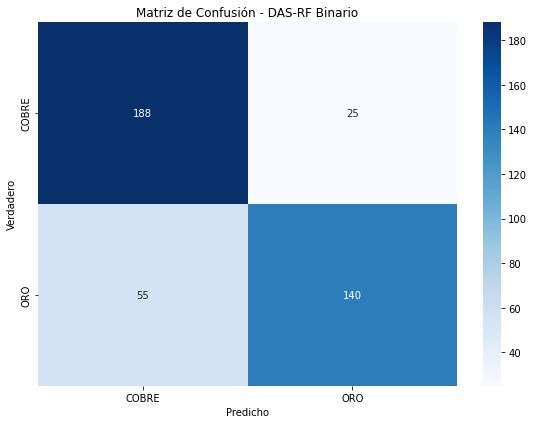

In [67]:
# ============================================================
# ENTRENAR DAS-RF CON DATOS BINARIOS
# ============================================================

# Verificar que tengas las variables preparadas
print("Verificando variables necesarias...")
print(f"✅ X_labeled_binario: {X_labeled_binario.shape}")
print(f"✅ y_labeled_binario: {y_labeled_binario.shape}")
print(f"✅ X_test_bin_scaled: {X_test_bin_scaled.shape}")
print(f"✅ y_test_bin_encoded: {y_test_bin_encoded.shape}")

# Si tienes datos no etiquetados
if 'X_unlabeled_binario' in locals():
    print(f"✅ X_unlabeled_binario: {X_unlabeled_binario.shape}")
else:
    print("⚠️  No se encontró X_unlabeled_binario")
    print("   Entrenando solo con datos etiquetados (sin semi-supervisado)")
    X_unlabeled_binario = None

# Crear y entrenar el modelo
dasrf_binario = DASRF(
    n_estimators=200,
    max_iter=30,
    temp_init=3.0,
    temp_min=0.5,
    cooling_rate=0.90,
    confidence_threshold=0.75,
    patience=5,
    random_state=42
)

# Entrenar
dasrf_binario.fit(
    X_labeled=X_labeled_binario,
    y_labeled=y_labeled_binario,
    X_unlabeled=X_unlabeled_binario
)

# Evaluar en test
y_pred_dasrf = dasrf_binario.predict(X_test_bin_scaled)
dasrf_acc = accuracy_score(y_test_bin_encoded, y_pred_dasrf)

print("\n" + "="*70)
print("📊 RESULTADOS EN TEST SET")
print("="*70)
print(f"🎯 DAS-RF Accuracy: {dasrf_acc:.4f}")

# Classification report
print("\n📊 Classification Report:")
print(classification_report(y_test_bin_encoded, y_pred_dasrf,
                          target_names=le_binario.classes_))

# Matriz de confusión
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_bin_encoded, y_pred_dasrf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_binario.classes_,
            yticklabels=le_binario.classes_)
plt.title('Matriz de Confusión - DAS-RF Binario')
plt.ylabel('Verdadero')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

📊 Distribución de confianzas en datos no etiquetados:
   Confianza promedio: 0.521
   Confianza máxima: 0.565
   Confianza mínima: 0.500
   Muestras con conf > 0.75: 0/119
   Muestras con conf > 0.70: 0/119
   Muestras con conf > 0.65: 0/119
   Muestras con conf > 0.60: 0/119


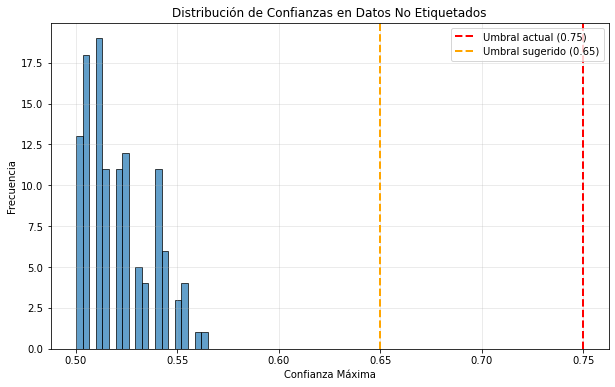

In [68]:
# Verificar las confianzas de los datos no etiquetados
rf_temp = RandomForestClassifier(n_estimators=200, random_state=42)
rf_temp.fit(X_labeled_binario, y_labeled_binario)
probs_unlabeled = rf_temp.predict_proba(X_unlabeled_binario)
max_confianzas = np.max(probs_unlabeled, axis=1)

print("📊 Distribución de confianzas en datos no etiquetados:")
print(f"   Confianza promedio: {np.mean(max_confianzas):.3f}")
print(f"   Confianza máxima: {np.max(max_confianzas):.3f}")
print(f"   Confianza mínima: {np.min(max_confianzas):.3f}")
print(f"   Muestras con conf > 0.75: {np.sum(max_confianzas > 0.75)}/119")
print(f"   Muestras con conf > 0.70: {np.sum(max_confianzas > 0.70)}/119")
print(f"   Muestras con conf > 0.65: {np.sum(max_confianzas > 0.65)}/119")
print(f"   Muestras con conf > 0.60: {np.sum(max_confianzas > 0.60)}/119")

# Histograma
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(max_confianzas, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(0.75, color='red', linestyle='--', linewidth=2, label='Umbral actual (0.75)')
plt.axvline(0.65, color='orange', linestyle='--', linewidth=2, label='Umbral sugerido (0.65)')
plt.xlabel('Confianza Máxima')
plt.ylabel('Frecuencia')
plt.title('Distribución de Confianzas en Datos No Etiquetados')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#